# Investigating MC files for determining good cut parameters

#### Extracting low level interaction parameters from mc

In [1]:
import awkward as ak
def extract_interaction_parameters(fobj,lep,CC): 
    
    E_lepIn = fobj.mc_tracks.E[:,0]
    E_lepOut = np.zeros_like(E_lepIn) 
    
    if lep == "electron" and CC == 1:
        is_e = np.abs(fobj.mc_tracks.pdgid) == 11
        E_lepOut = fobj.mc_tracks.E[is_e][:,0]
    elif lep == "electron" and CC == 0:
        is_nue = np.abs(fobj.mc_tracks.pdgid) == 12
        E_lepOut = fobj.mc_tracks.E[is_nue][:,1]
    elif lep == "muon" and CC == 1:
        is_num = np.abs(fobj.mc_tracks.pdgid) == 13
        print(is_num)
        selected = fobj.mc_tracks[is_num]
        E_lepOut = ak.firsts(selected.E)
        print(E_lepOut)
        #E_lepOut = fobj.mc_tracks.E[is_num][:,0]
    elif lep == "muon" and CC == 0:
        is_num = np.abs(fobj.mc_tracks.pdgid) == 14
        E_lepOut = fobj.mc_tracks.E[is_num][:,1]
    else: print("Only possible for electrons and muons!")
    
    E_lepIn = ak.to_numpy(E_lepIn)
    print(E_lepIn)
    E_lepOut = ak.to_numpy(E_lepOut)    

    By1 = 1 - E_lepOut/E_lepIn
    
    By2 = fobj.w2list[:,8]
    By2 = ak.to_numpy(By2)
    
    Bx = fobj.w2list[:,7]
    Bx = ak.to_numpy(Bx)
    
    #scat_angle = scatangle_function(fobj,lep,CC)
    #scat_angle = ak.to_numpy(scat_angle)
    
    xsec = fobj.w2list[:,13]
    xsec = ak.to_numpy(xsec)
    
    weight = fobj.w[:,1]
    weight = ak.to_numpy(weight)
    weight = weight/len(E_lepIn)*np.power(E_lepIn,-1.4)
    
    return By1,By2,E_lepIn, E_lepOut, Bx , xsec, weight

#By1,By2,E_lepIn, E_lepOut, Bx , xsec, weight = extract_function(OfflineObject_mc,'muon', 1)

#### Loading files, extracting and concatenating best fits 

In [2]:
from km3io import OfflineReader, tools
from km3astro.coord import local_event
import numpy as np
from km3astro.io import root_to_hdf5, load_hdf5_tables
import os
import matplotlib.pyplot as plt
from km3io.tools import fitinf
import km3io.definitions as kd
from astropy.time import Time

def dir_to_spherical(tracks):
    """
    Convert directional coordinates (x, y, z) to spherical coordinates (theta, phi).
    """
    vec = np.array([tracks.dir_x, tracks.dir_y, tracks.dir_z])
    vec = np.transpose(vec)
    theta_val = tools.theta(vec)
    phi_val = tools.phi(vec)
    return theta_val, phi_val

def get_utc_timeslice(OfflineObject):
    """
    Calculate UTC time of the timeslices where the events were put based on input data.
    """
    sec = OfflineObject.t_sec
    tns = OfflineObject.t_ns
    S_TO_NS = np.uint64(1e9)
    times = sec + tns / S_TO_NS  # Combine seconds and nanoseconds to get time in seconds
    astropy_times = Time(sec, tns / S_TO_NS, format="unix")
    return times, astropy_times

def get_utc_tracktime(timeslice, tracktimes):
    """
    Calculate UTC time of the track times based on timeslices and track times.
    """
    S_TO_NS = np.uint64(1e9)
    times = timeslice + tracktimes / S_TO_NS  # Combine seconds and nanoseconds to get time in seconds
    astropy_times = Time(timeslice, tracktimes / S_TO_NS, format="unix")
    return times, astropy_times


def load_and_combine(file_list_path):

    # Read all file paths from the text file
    with open(file_list_path, "r") as f:
        root_files = [line.strip() for line in f if line.strip()]

    # Initialize lists to collect data
    mc_beta0_jm_list = []
    mc_beta1_jm_list = []
    nhits_jm_list = []
    nhits_as_list = []
    separation_jm_list = []
    separation_as_list = []
    E_jm_list = []
    E_as_list = []
    E_mc_list = []
    E_jm_diff_list = []
    E_as_diff_list = []
    lik_jm_list= []
    lik_as_list = []
    chi2_jm_list = []

    # Loop through each file
    for rootpath_mc in root_files:
        print(f"Processing {rootpath_mc}, size: {os.path.getsize(rootpath_mc) / 1e6:.2f} MB")
        
        # Read the OfflineObject from the file
        OfflineObject_mc = OfflineReader(rootpath_mc)
        print(len(OfflineObject_mc))
        
        # Extract and store best fits and masks for jmuon
        mc_best_fit_jm = tools.best_jmuon(OfflineObject_mc.tracks)
        mc_mask_jm = tools.has_jmuon(OfflineObject_mc.tracks)
        
        # Extract and store best fits and masks for aashower
        mc_best_fit_as = tools.best_aashower(OfflineObject_mc.tracks)
        mc_mask_as = tools.has_aashower(OfflineObject_mc.tracks)

        # Extract additional data
        theta_jm, phi_jm = dir_to_spherical(mc_best_fit_jm[mc_mask_jm])
        theta_as, phi_as = dir_to_spherical(mc_best_fit_as[mc_mask_as])
        theta_mc, phi_mc = dir_to_spherical(OfflineObject_mc.mc_trks[:, 0])

        E_jm = mc_best_fit_jm[mc_mask_jm].E.to_numpy()
        E_as = mc_best_fit_as[mc_mask_as].E.to_numpy()
        E_mc = OfflineObject_mc.mc_trks[:, 0].E.to_numpy()
        E_jm_list.append(E_jm)
        E_as_list.append(E_as)
        E_mc_list.append(E_mc)

        E_jm_diff = (E_jm - E_mc[mc_mask_jm])/E_mc[mc_mask_jm]
        E_as_diff = (E_as - E_mc[mc_mask_as])/E_mc[mc_mask_as]
        E_jm_diff_list.append(E_jm_diff)
        E_as_diff_list.append(E_as_diff)

        lik_jm = mc_best_fit_jm[mc_mask_jm].lik.to_numpy()
        lik_as = mc_best_fit_as[mc_mask_as].lik.to_numpy()
        lik_jm_list.append(lik_jm)
        lik_as_list.append(lik_as)

        # Fitting parameters
        # Jmuon beta0
        mc_beta0_jm = fitinf(kd.fitparameters.JGANDALF_BETA0_RAD, mc_best_fit_jm[mc_mask_jm])
        mc_beta0_jm_list.append(mc_beta0_jm)

        # Jmuon beta1
        mc_beta1_jm = fitinf(kd.fitparameters.JGANDALF_BETA1_RAD, mc_best_fit_jm[mc_mask_jm])
        mc_beta1_jm_list.append(mc_beta1_jm)
        
        # Jmuon number of hits
        nhits_jm = fitinf(kd.fitparameters.JGANDALF_NUMBER_OF_HITS, mc_best_fit_jm[mc_mask_jm])
        nhits_jm_list.append(nhits_jm)
        
        # Aashower number of hits
        nhits_as = fitinf(kd.fitparameters.AASHOWERFIT_NUMBER_OF_HITS, mc_best_fit_as[mc_mask_as])
        nhits_as_list.append(nhits_as)

        chi2_jm = fitinf(kd.fitparameters.JGANDALF_CHI2, mc_best_fit_jm[mc_mask_jm])
        chi2_jm_list.append(chi2_jm)

        times, astropy_times = get_utc_timeslice(OfflineObject_mc)
        tracktimes_jm, astropy_tracktimes_jm = get_utc_tracktime(times[mc_mask_jm], mc_best_fit_jm[mc_mask_jm].t)
        tracktimes_as, astropy_tracktimes_as = get_utc_tracktime(times[mc_mask_as], mc_best_fit_as[mc_mask_as].t)

        # Detector location
        detector_location = 'arca'

        # Reconstruct event locations
        reco_location_jm = local_event(np.array(theta_jm), np.array(phi_jm), astropy_tracktimes_jm, detector_location)
        reco_location_as = local_event(np.array(theta_as), np.array(phi_as), astropy_tracktimes_as, detector_location)
        mc_location = local_event(np.array(theta_mc), np.array(phi_mc), astropy_times, detector_location)

        # Compute separation values
        separation_jm = reco_location_jm.separation(mc_location[mc_mask_jm])
        separation_as = reco_location_as.separation(mc_location[mc_mask_as])
        
        print(f"Separation JMuon: {separation_jm.value}")
        print(f"Separation AShower: {separation_as.value}")
        
        # Store the separations for later analysis
        separation_jm_list.append(separation_jm.value)
        separation_as_list.append(separation_as.value)

    # After processing all files, you can analyze the separation data
    all_separation_jm = np.concatenate(separation_jm_list)
    all_separation_as = np.concatenate(separation_as_list)
    all_mc_beta0_jm = np.concatenate(mc_beta0_jm_list)
    all_mc_beta1_jm = np.concatenate(mc_beta1_jm_list)
    all_nhits_jm = np.concatenate(nhits_jm_list)
    all_nhits_as = np.concatenate(nhits_as_list)
    all_E_jm = np.concatenate(E_jm_list)
    all_E_as = np.concatenate(E_as_list)
    all_E_mc = np.concatenate(E_mc_list)
    all_E_jm_diff = np.concatenate(E_jm_diff_list)
    all_E_as_diff = np.concatenate(E_as_diff_list)
    all_lik_jm = np.concatenate(lik_jm_list)
    all_lik_as = np.concatenate(lik_as_list)
    all_chi2_jm = np.concatenate(chi2_jm_list)

    return all_separation_jm, all_separation_as, all_mc_beta0_jm, all_mc_beta1_jm, all_nhits_jm, all_nhits_as, all_E_jm, all_E_as, all_E_mc, all_E_jm_diff, all_E_as_diff, all_lik_jm, all_lik_as, all_chi2_jm


In [12]:
"arca"

'arca'

In [3]:
file_list_path_shower = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/mc_files_arca_anue.txt"
file_list_path_track = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/mc_files_arca_numu.txt"

s_all_separation_jm, s_all_separation_as, s_all_mc_beta0_jm, s_all_mc_beta1_jm, s_all_nhits_jm, s_all_nhits_as, s_all_E_jm, s_all_E_as, s_all_E_mc, s_all_E_jm_diff, s_all_E_as_diff, s_all_lik_jm, s_all_lik_as, s_all_chi2_jm = load_and_combine(file_list_path_shower)
t_all_separation_jm, t_all_separation_as, t_all_mc_beta0_jm, t_all_mc_beta1_jm, t_all_nhits_jm, t_all_nhits_as, t_all_E_jm, t_all_E_as, t_all_E_mc, t_all_E_jm_diff, t_all_E_as_diff, t_all_lik_jm, t_all_lik_as, t_all_chi2_jm = load_and_combine(file_list_path_track)

file_list_path_both = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/mc_files_arca.txt"
b_all_separation_jm, b_all_separation_as, b_all_mc_beta0_jm, b_all_mc_beta1_jm, b_all_nhits_jm, b_all_nhits_as, b_all_E_jm, b_all_E_as, b_all_E_mc, b_all_E_jm_diff, b_all_E_as_diff, b_all_lik_jm, b_all_lik_as, b_all_chi2_jm = load_and_combine(file_list_path_both)


Processing /home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root, size: 1626.55 MB
13274
Separation JMuon: [43.80494886 75.71714859 65.19201234 ... 20.84397388 48.74490079
 61.35629505]
Separation AShower: [44.97115448  1.31899907 40.77851108 ... 35.72245413 64.43626076
 22.52394045]
Processing /home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013289.jchain.aashower.2.root, size: 1630.48 MB
13309
Separation JMuon: [ 24.64673516  74.89466687 100.62095302 ... 122.45103631  20.15531278
  47.99847262]
Separation AShower: [46.7630052  10.06650787 22.80746486 ... 46.82720326 43.82764311
 25.53329157]
Processing /home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013290.jchain.aashower.3.root, size: 1623.73 MB
13312
Separation JMuon: [ 12.82155529 105.1148909  136.33643539 ...  19.08759051  92.43436678
  75.21465447]
Separation AShower: [13.26874862 20.99344958 30.6136

In [14]:
print(len(t_all_E_as))
print(len(t_all_E_jm))
print(len(s_all_E_as))
print(len(s_all_E_jm))
print(len(b_all_E_as))
print(len(b_all_E_jm))

88067
78556
132676
112661
220743
191217


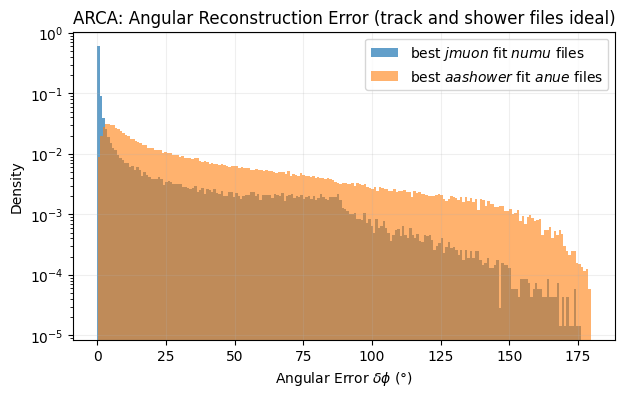

In [26]:
# Example of plotting the separations
output_plot = "/home/hpc/capn/capn107h/software/psr/plots/arca_angular_recoerror_numu_and_anue_files_ideal.png"

plt.figure(figsize=(7, 4))
plt.hist(t_all_separation_jm, bins=200, alpha=0.7, label=r'best $\it{jmuon}$ fit $\it{numu}$ files', density=True, log = True)
plt.hist(s_all_separation_as, bins=200, alpha=0.6, label=r'best $\it{aashower}$ fit $\it{anue}$ files', density=True, log=True)
plt.legend()
plt.xlabel(r'Angular Error $\delta \phi$ (°)')
plt.ylabel('Density')
plt.title(r'ARCA: Angular Reconstruction Error (track and shower files ideal)')
plt.grid(alpha=0.2)
plt.savefig(output_plot, bbox_inches='tight')
plt.show()

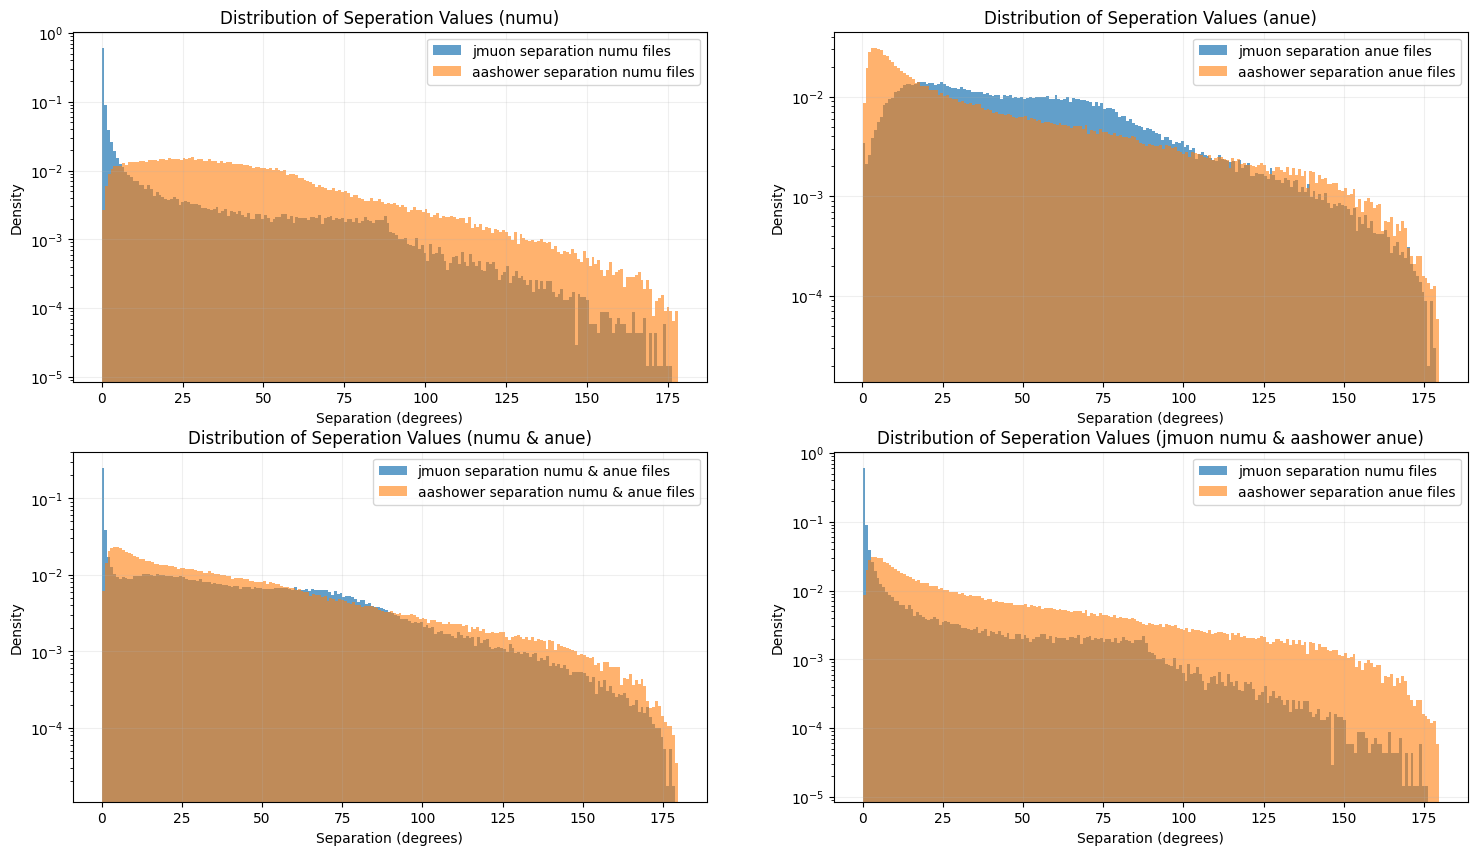

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
ax = axs[0][0]
ax.hist(t_all_separation_jm, bins=200, alpha=0.7, label='jmuon separation numu files', density=True, log = True)
ax.hist(t_all_separation_as, bins=200, alpha=0.6, label='aashower separation numu files', density=True, log=True)
ax.legend()
ax.set_xlabel('Separation (degrees)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Seperation Values (numu)')
ax.grid(alpha=0.2)

ax = axs[0][1]
ax.hist(s_all_separation_jm, bins=200, alpha=0.7, label='jmuon separation anue files', density=True, log = True)
ax.hist(s_all_separation_as, bins=200, alpha=0.6, label='aashower separation anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('Separation (degrees)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Seperation Values (anue)')
ax.grid(alpha=0.2)

ax = axs[1][0]
ax.hist(b_all_separation_jm, bins=200, alpha=0.7, label='jmuon separation numu & anue files', density=True, log = True)
ax.hist(b_all_separation_as, bins=200, alpha=0.6, label='aashower separation numu & anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('Separation (degrees)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Seperation Values (numu & anue)')
ax.grid(alpha=0.2)

ax = axs[1][1]
ax.hist(t_all_separation_jm, bins=200, alpha=0.7, label='jmuon separation numu files', density=True, log = True)
ax.hist(s_all_separation_as, bins=200, alpha=0.6, label='aashower separation anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('Separation (degrees)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Seperation Values (jmuon numu & aashower anue)')
ax.grid(alpha=0.2)

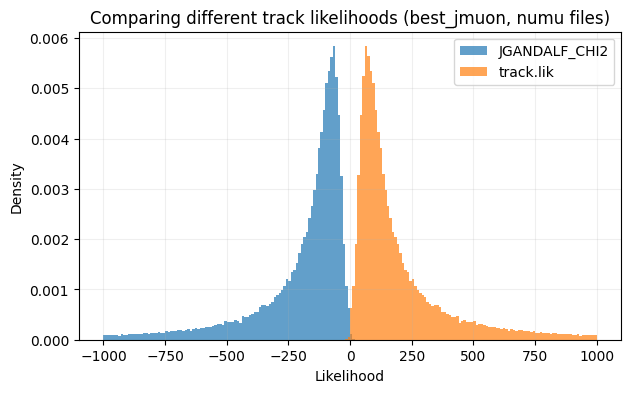

In [37]:
# Example of plotting the likelihoods
plt.figure(figsize=(7, 4))
plt.hist(t_all_chi2_jm, bins=200, range=(-1000,1000), alpha=0.7, label='JGANDALF_CHI2', density=True)
plt.hist(t_all_lik_jm, bins=200, range=(-1000,1000), alpha=0.7, label='track.lik', density=True)
plt.legend()
plt.xlabel('Likelihood')
plt.ylabel('Density')
plt.title('Comparing different track likelihoods (best_jmuon, numu files)')
plt.grid(alpha=0.2)
plt.show()

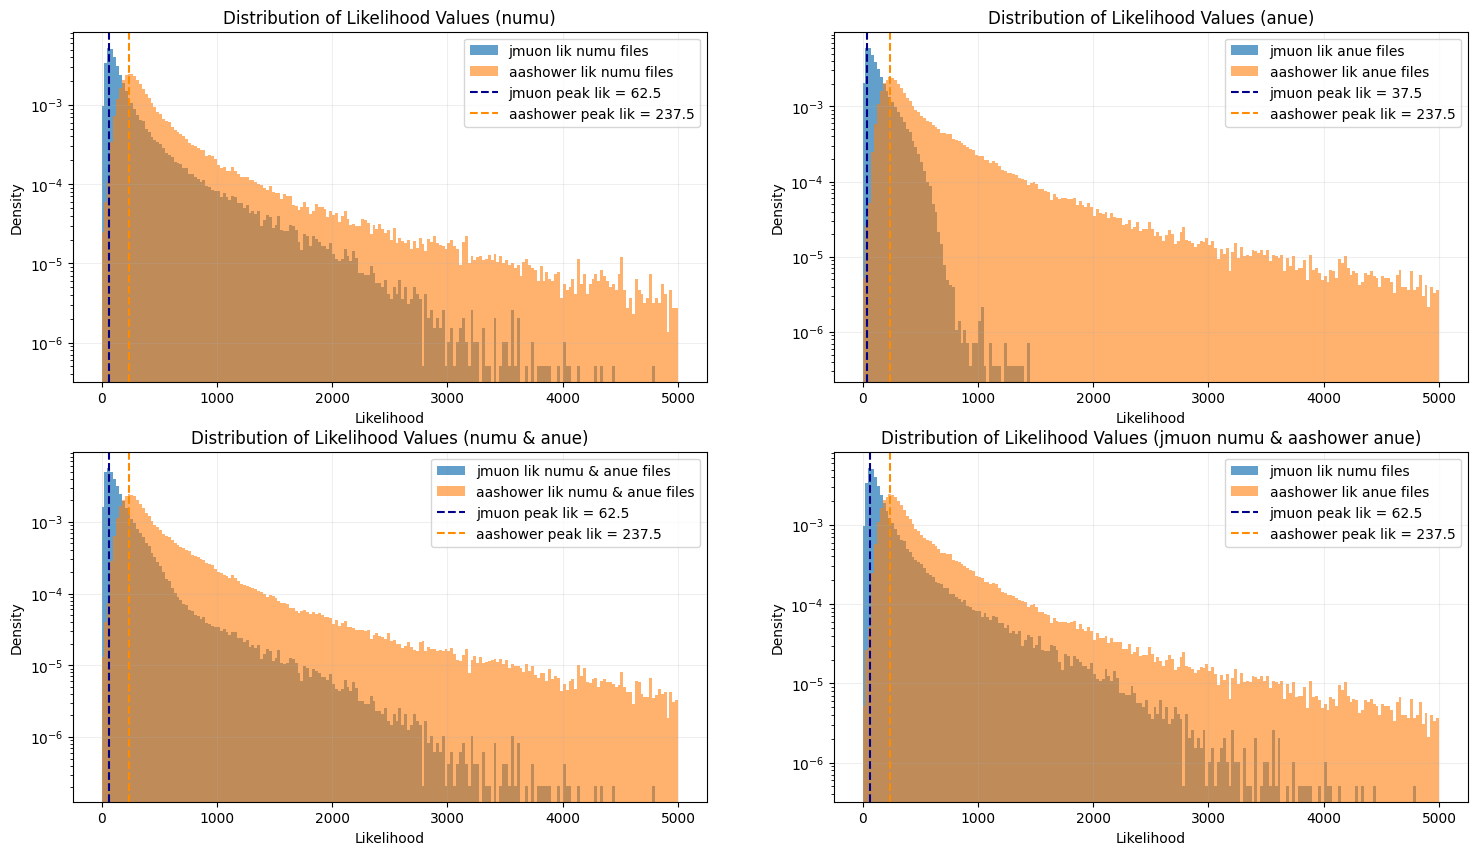

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
ax = axs[0][0]
ax.hist(t_all_lik_jm, bins=200, range=(0,5000), alpha=0.7, label='jmuon lik numu files', density=True, log = True)
ax.hist(-t_all_lik_as, bins=200, range=(0,5000), alpha=0.6, label='aashower lik numu files', density=True, log=True)
ax.legend()
ax.set_xlabel('Likelihood')
ax.set_ylabel('Density')
ax.set_title('Distribution of Likelihood Values (numu)')
ax.grid(alpha=0.2)

# Plot histograms
lik_jm, bins_jm = np.histogram(t_all_lik_jm, bins=200, range=(0, 5000), density=True)
lik_as, bins_as = np.histogram(-t_all_lik_as, bins=200, range=(0, 5000), density=True)

# Find maxima
max_bin_index_jm = np.argmax(lik_jm)
max_lik_jm = 0.5 * (bins_jm[max_bin_index_jm] + bins_jm[max_bin_index_jm + 1])

max_bin_index_as = np.argmax(lik_as)
max_lik_as = 0.5 * (bins_as[max_bin_index_as] + bins_as[max_bin_index_as + 1])

# Plot vertical lines at maxima
ax.axvline(max_lik_jm, color='darkblue', linestyle='--', label=f'jmuon peak lik = {max_lik_jm:.1f}')
ax.axvline(max_lik_as, color='darkorange', linestyle='--', label=f'aashower peak lik = {max_lik_as:.1f}')
ax.legend()

ax = axs[0][1]
ax.hist(s_all_lik_jm, bins=200, range=(0,5000), alpha=0.7, label='jmuon lik anue files', density=True, log = True)
ax.hist(-s_all_lik_as, bins=200, range=(0,5000), alpha=0.6, label='aashower lik anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('Likelihood')
ax.set_ylabel('Density')
ax.set_title('Distribution of Likelihood Values (anue)')
ax.grid(alpha=0.2)

# Plot histograms
lik_jm, bins_jm = np.histogram(s_all_lik_jm, bins=200, range=(0, 5000), density=True)
lik_as, bins_as = np.histogram(-s_all_lik_as, bins=200, range=(0, 5000), density=True)

# Find maxima
max_bin_index_jm = np.argmax(lik_jm)
max_lik_jm = 0.5 * (bins_jm[max_bin_index_jm] + bins_jm[max_bin_index_jm + 1])

max_bin_index_as = np.argmax(lik_as)
max_lik_as = 0.5 * (bins_as[max_bin_index_as] + bins_as[max_bin_index_as + 1])

# Plot vertical lines at maxima
ax.axvline(max_lik_jm, color='darkblue', linestyle='--', label=f'jmuon peak lik = {max_lik_jm:.1f}')
ax.axvline(max_lik_as, color='darkorange', linestyle='--', label=f'aashower peak lik = {max_lik_as:.1f}')
ax.legend()

ax = axs[1][0]
ax.hist(b_all_lik_jm, bins=200, range=(0,5000), alpha=0.7, label='jmuon lik numu & anue files', density=True, log = True)
ax.hist(-b_all_lik_as, bins=200, range=(0,5000), alpha=0.6, label='aashower lik numu & anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('Likelihood')
ax.set_ylabel('Density')
ax.set_title('Distribution of Likelihood Values (numu & anue)')
ax.grid(alpha=0.2)

# Plot histograms
lik_jm, bins_jm = np.histogram(b_all_lik_jm, bins=200, range=(0, 5000), density=True)
lik_as, bins_as = np.histogram(-b_all_lik_as, bins=200, range=(0, 5000), density=True)

# Find maxima
max_bin_index_jm = np.argmax(lik_jm)
max_lik_jm = 0.5 * (bins_jm[max_bin_index_jm] + bins_jm[max_bin_index_jm + 1])

max_bin_index_as = np.argmax(lik_as)
max_lik_as = 0.5 * (bins_as[max_bin_index_as] + bins_as[max_bin_index_as + 1])

# Plot vertical lines at maxima
ax.axvline(max_lik_jm, color='darkblue', linestyle='--', label=f'jmuon peak lik = {max_lik_jm:.1f}')
ax.axvline(max_lik_as, color='darkorange', linestyle='--', label=f'aashower peak lik = {max_lik_as:.1f}')
ax.legend()

ax = axs[1][1]
ax.hist(t_all_lik_jm, bins=200, range=(0,5000), alpha=0.7, label='jmuon lik numu files', density=True, log = True)
ax.hist(-s_all_lik_as, bins=200, range=(0,5000), alpha=0.6, label='aashower lik anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('Likelihood')
ax.set_ylabel('Density')
ax.set_title('Distribution of Likelihood Values (jmuon numu & aashower anue)')
ax.grid(alpha=0.2)

# Plot histograms
lik_jm, bins_jm = np.histogram(t_all_lik_jm, bins=200, range=(0, 5000), density=True)
lik_as, bins_as = np.histogram(-s_all_lik_as, bins=200, range=(0, 5000), density=True)

# Find maxima
max_bin_index_jm = np.argmax(lik_jm)
max_lik_jm = 0.5 * (bins_jm[max_bin_index_jm] + bins_jm[max_bin_index_jm + 1])

max_bin_index_as = np.argmax(lik_as)
max_lik_as = 0.5 * (bins_as[max_bin_index_as] + bins_as[max_bin_index_as + 1])

# Plot vertical lines at maxima
ax.axvline(max_lik_jm, color='darkblue', linestyle='--', label=f'jmuon peak lik = {max_lik_jm:.1f}')
ax.axvline(max_lik_as, color='darkorange', linestyle='--', label=f'aashower peak lik = {max_lik_as:.1f}')
ax.legend()

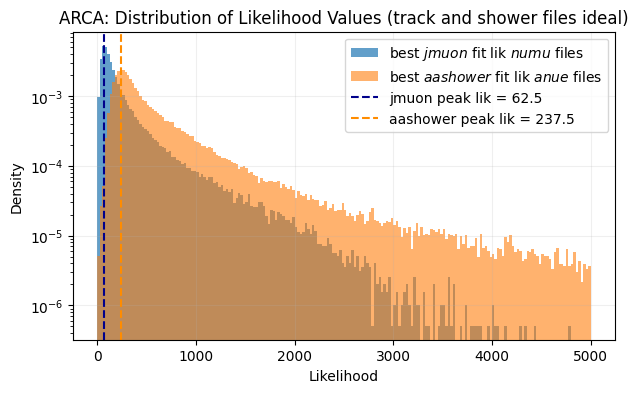

In [38]:
output_plot = "/home/hpc/capn/capn107h/software/psr/plots/arca_likelihoods_numu_and_anue_files_ideal.png"

fig, ax = plt.subplots(figsize=(7, 4))
plt.hist(t_all_lik_jm, bins=200, range=(0,5000), alpha=0.7, label=r'best $\it{jmuon}$ fit lik $\it{numu}$ files', density=True, log = True)
plt.hist(-s_all_lik_as, bins=200, range=(0,5000), alpha=0.6, label=r'best $\it{aashower}$ fit lik $\it{anue}$ files', density=True, log=True)
ax.legend()
ax.set_xlabel('Likelihood')
ax.set_ylabel('Density')
ax.set_title(r'ARCA: Distribution of Likelihood Values (track and shower files ideal)')
ax.grid(alpha=0.2)

# Plot histograms
lik_jm, bins_jm = np.histogram(t_all_lik_jm, bins=200, range=(0, 5000), density=True)
lik_as, bins_as = np.histogram(-t_all_lik_as, bins=200, range=(0, 5000), density=True)

# Find maxima
max_bin_index_jm = np.argmax(lik_jm)
max_lik_jm = 0.5 * (bins_jm[max_bin_index_jm] + bins_jm[max_bin_index_jm + 1])

max_bin_index_as = np.argmax(lik_as)
max_lik_as = 0.5 * (bins_as[max_bin_index_as] + bins_as[max_bin_index_as + 1])

# Plot vertical lines at maxima
ax.axvline(max_lik_jm, color='darkblue', linestyle='--', label=f'jmuon peak lik = {max_lik_jm:.1f}')
ax.axvline(max_lik_as, color='darkorange', linestyle='--', label=f'aashower peak lik = {max_lik_as:.1f}')
plt.legend()
plt.savefig(output_plot, bbox_inches='tight')

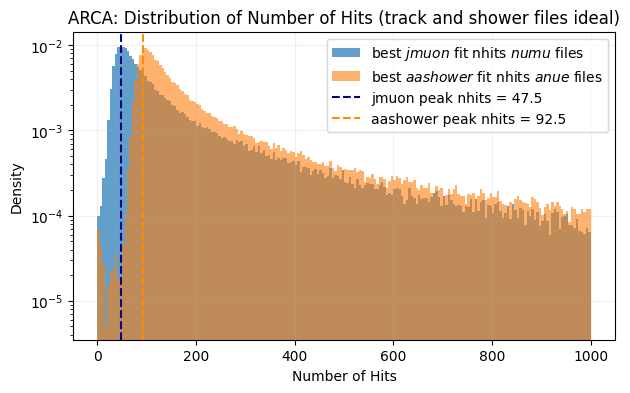

In [44]:
output_plot = "/home/hpc/capn/capn107h/software/psr/plots/arca_nhits_numu_and_anue_files_ideal.png"
fig, ax = plt.subplots(figsize=(7, 4))

plt.hist(t_all_nhits_jm, bins=200, range=(0,1000), alpha=0.7, label=r'best $\it{jmuon}$ fit nhits $\it{numu}$ files', density=True, log = True)
plt.hist(s_all_nhits_as, bins=200, range=(0,1000), alpha=0.6, label=r'best $\it{aashower}$ fit nhits $\it{anue}$ files', density=True, log=True)

ax.set_xlabel('Number of Hits')
ax.set_ylabel('Density')
ax.set_title('ARCA: Distribution of Number of Hits (track and shower files ideal)')
ax.grid(alpha=0.2)

# Plot histograms
n_jm, bins_jm = np.histogram(t_all_nhits_jm, bins=200, range=(0, 1000), density=True)
n_as, bins_as = np.histogram(t_all_nhits_as, bins=200, range=(0, 1000), density=True)

# Find maxima
max_bin_index_jm = np.argmax(n_jm)
max_nhits_jm = 0.5 * (bins_jm[max_bin_index_jm] + bins_jm[max_bin_index_jm + 1])

max_bin_index_as = np.argmax(n_as)
max_nhits_as = 0.5 * (bins_as[max_bin_index_as] + bins_as[max_bin_index_as + 1])

# Plot vertical lines at maxima
ax.axvline(max_nhits_jm, color='darkblue', linestyle='--', label=f'jmuon peak nhits = {max_nhits_jm:.1f}')
ax.axvline(max_nhits_as, color='darkorange', linestyle='--', label=f'aashower peak nhits = {max_nhits_as:.1f}')
plt.legend()
plt.savefig(output_plot, bbox_inches='tight')

In [ ]:
output_plot = "/home/hpc/capn/capn107h/software/psr/plots/arca_energy_difference_numu_files.png"

plt.figure(figsize=(7, 4))
plt.hist(t_all_E_jm_diff, bins=200, range=(-1,1), alpha=0.7, label='numu: E_jmuon - E_mctrue', density=True,log=True)
plt.hist(s_all_E_as_diff, bins=200, range=(-1,1), alpha=0.7, label='anue: E_aashower - E_mctrue', density=True,log=True)
plt.legend()
plt.xlabel(r'$E_{reco}-E_{mc}$')
plt.ylabel('Density')
plt.title(r'Distribution of Energy Difference (track files only)')
plt.grid(alpha=0.2)
plt.show()

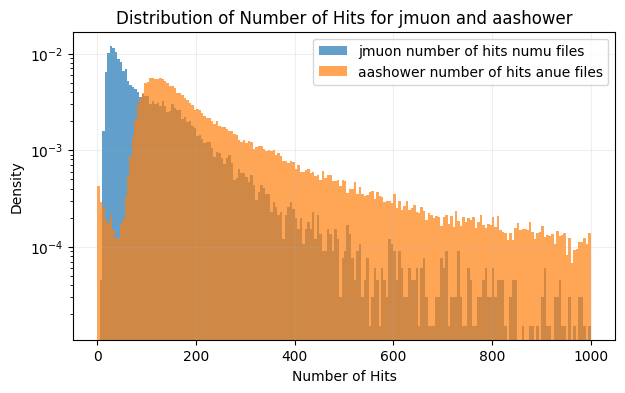

In [ ]:
# Example of plotting the separations
plt.figure(figsize=(7, 4))
plt.hist(t_all_nhits_jm, bins=200, range=(0,1000), alpha=0.7, label='jmuon number of hits numu files', density=True, log=True)
plt.hist(s_all_nhits_as, bins=200, range=(0,1000), alpha=0.7, label='aashower number of hits anue files', density=True, log=True)
plt.legend()
plt.xlabel('Number of Hits')
plt.ylabel('Density')
plt.title('Distribution of Number of Hits for jmuon and aashower')
plt.grid(alpha=0.2)
plt.show()



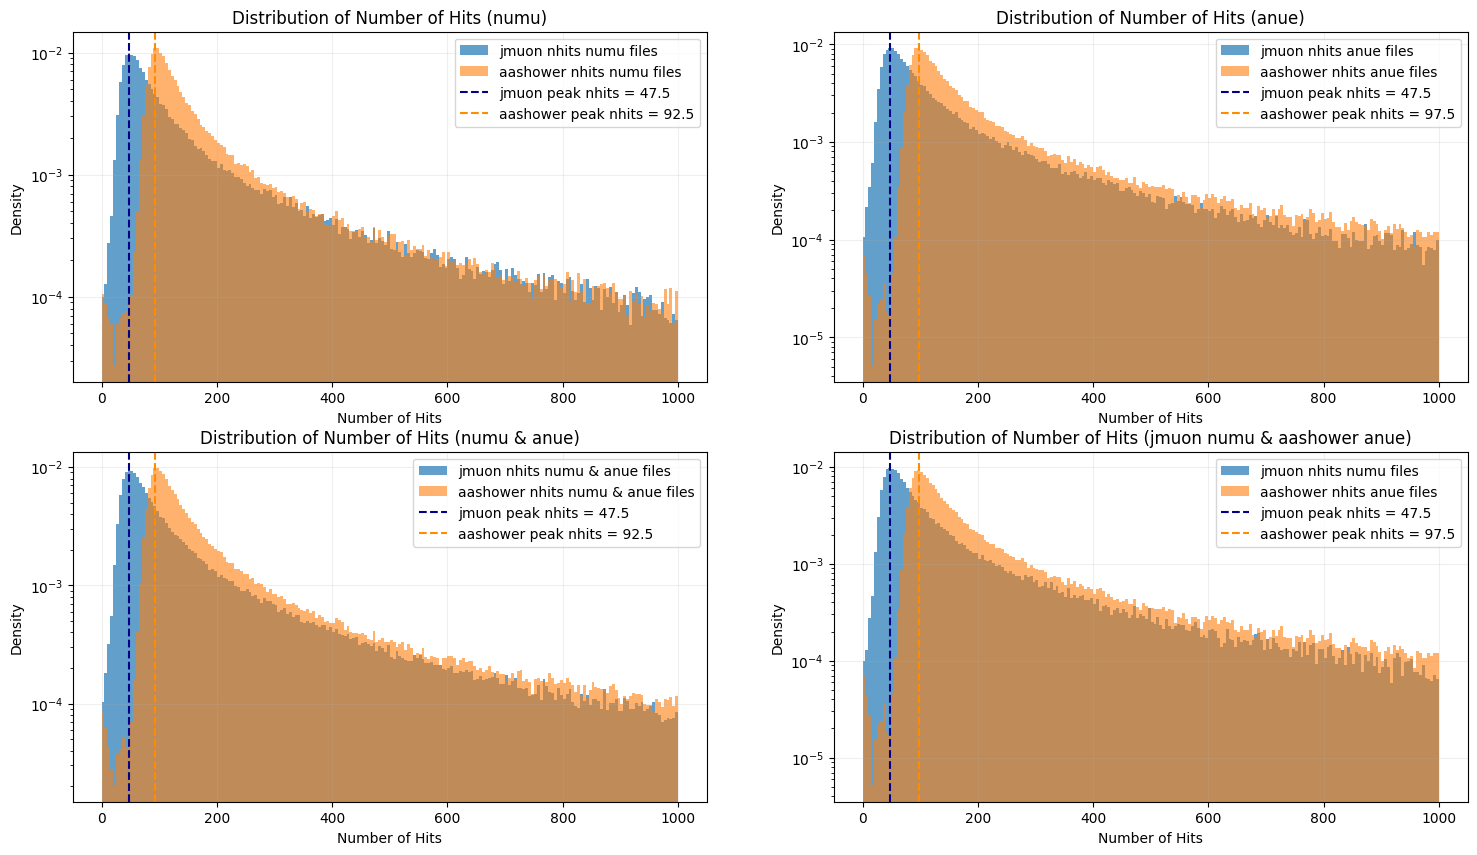

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
ax = axs[0][0]
ax.hist(t_all_nhits_jm, bins=200, range=(0,1000), alpha=0.7, label='jmuon nhits numu files', density=True, log = True)
ax.hist(t_all_nhits_as, bins=200, range=(0,1000), alpha=0.6, label='aashower nhits numu files', density=True, log=True)

ax.set_xlabel('Number of Hits')
ax.set_ylabel('Density')
ax.set_title('Distribution of Number of Hits (numu)')
ax.grid(alpha=0.2)

# Plot histograms
n_jm, bins_jm = np.histogram(t_all_nhits_jm, bins=200, range=(0, 1000), density=True)
n_as, bins_as = np.histogram(t_all_nhits_as, bins=200, range=(0, 1000), density=True)

# Find maxima
max_bin_index_jm = np.argmax(n_jm)
max_nhits_jm = 0.5 * (bins_jm[max_bin_index_jm] + bins_jm[max_bin_index_jm + 1])

max_bin_index_as = np.argmax(n_as)
max_nhits_as = 0.5 * (bins_as[max_bin_index_as] + bins_as[max_bin_index_as + 1])

# Plot vertical lines at maxima
ax.axvline(max_nhits_jm, color='darkblue', linestyle='--', label=f'jmuon peak nhits = {max_nhits_jm:.1f}')
ax.axvline(max_nhits_as, color='darkorange', linestyle='--', label=f'aashower peak nhits = {max_nhits_as:.1f}')
ax.legend()

ax = axs[0][1]
ax.hist(s_all_nhits_jm, bins=200, range=(0,1000), alpha=0.7, label='jmuon nhits anue files', density=True, log = True)
ax.hist(s_all_nhits_as, bins=200, range=(0,1000), alpha=0.6, label='aashower nhits anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('Number of Hits')
ax.set_ylabel('Density')
ax.set_title('Distribution of Number of Hits (anue)')
ax.grid(alpha=0.2)

# Plot histograms
n_jm, bins_jm = np.histogram(s_all_nhits_jm, bins=200, range=(0, 1000), density=True)
n_as, bins_as = np.histogram(s_all_nhits_as, bins=200, range=(0, 1000), density=True)

# Find maxima
max_bin_index_jm = np.argmax(n_jm)
max_nhits_jm = 0.5 * (bins_jm[max_bin_index_jm] + bins_jm[max_bin_index_jm + 1])

max_bin_index_as = np.argmax(n_as)
max_nhits_as = 0.5 * (bins_as[max_bin_index_as] + bins_as[max_bin_index_as + 1])

# Plot vertical lines at maxima
ax.axvline(max_nhits_jm, color='darkblue', linestyle='--', label=f'jmuon peak nhits = {max_nhits_jm:.1f}')
ax.axvline(max_nhits_as, color='darkorange', linestyle='--', label=f'aashower peak nhits = {max_nhits_as:.1f}')
ax.legend()

ax = axs[1][0]
ax.hist(b_all_nhits_jm, bins=200, range=(0,1000), alpha=0.7, label='jmuon nhits numu & anue files', density=True, log = True)
ax.hist(b_all_nhits_as, bins=200, range=(0,1000), alpha=0.6, label='aashower nhits numu & anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('Number of Hits')
ax.set_ylabel('Density')
ax.set_title('Distribution of Number of Hits (numu & anue)')
ax.grid(alpha=0.2)

# Plot histograms
n_jm, bins_jm = np.histogram(b_all_nhits_jm, bins=200, range=(0, 1000), density=True)
n_as, bins_as = np.histogram(b_all_nhits_as, bins=200, range=(0, 1000), density=True)

# Find maxima
max_bin_index_jm = np.argmax(n_jm)
max_nhits_jm = 0.5 * (bins_jm[max_bin_index_jm] + bins_jm[max_bin_index_jm + 1])

max_bin_index_as = np.argmax(n_as)
max_nhits_as = 0.5 * (bins_as[max_bin_index_as] + bins_as[max_bin_index_as + 1])

# Plot vertical lines at maxima
ax.axvline(max_nhits_jm, color='darkblue', linestyle='--', label=f'jmuon peak nhits = {max_nhits_jm:.1f}')
ax.axvline(max_nhits_as, color='darkorange', linestyle='--', label=f'aashower peak nhits = {max_nhits_as:.1f}')
ax.legend()

ax = axs[1][1]
ax.hist(t_all_nhits_jm, bins=200, range=(0,1000), alpha=0.7, label='jmuon nhits numu files', density=True, log = True)
ax.hist(s_all_nhits_as, bins=200, range=(0,1000), alpha=0.6, label='aashower nhits anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('Number of Hits')
ax.set_ylabel('Density')
ax.set_title('Distribution of Number of Hits (jmuon numu & aashower anue)')
ax.grid(alpha=0.2)

# Plot histograms
n_jm, bins_jm = np.histogram(t_all_nhits_jm, bins=200, range=(0, 1000), density=True)
n_as, bins_as = np.histogram(s_all_nhits_as, bins=200, range=(0, 1000), density=True)

# Find maxima
max_bin_index_jm = np.argmax(n_jm)
max_nhits_jm = 0.5 * (bins_jm[max_bin_index_jm] + bins_jm[max_bin_index_jm + 1])

max_bin_index_as = np.argmax(n_as)
max_nhits_as = 0.5 * (bins_as[max_bin_index_as] + bins_as[max_bin_index_as + 1])

# Plot vertical lines at maxima
ax.axvline(max_nhits_jm, color='darkblue', linestyle='--', label=f'jmuon peak nhits = {max_nhits_jm:.1f}')
ax.axvline(max_nhits_as, color='darkorange', linestyle='--', label=f'aashower peak nhits = {max_nhits_as:.1f}')
ax.legend()

In [48]:
print(np.min(t_all_nhits_jm))
print(np.min(s_all_nhits_as))

0.0
2.0


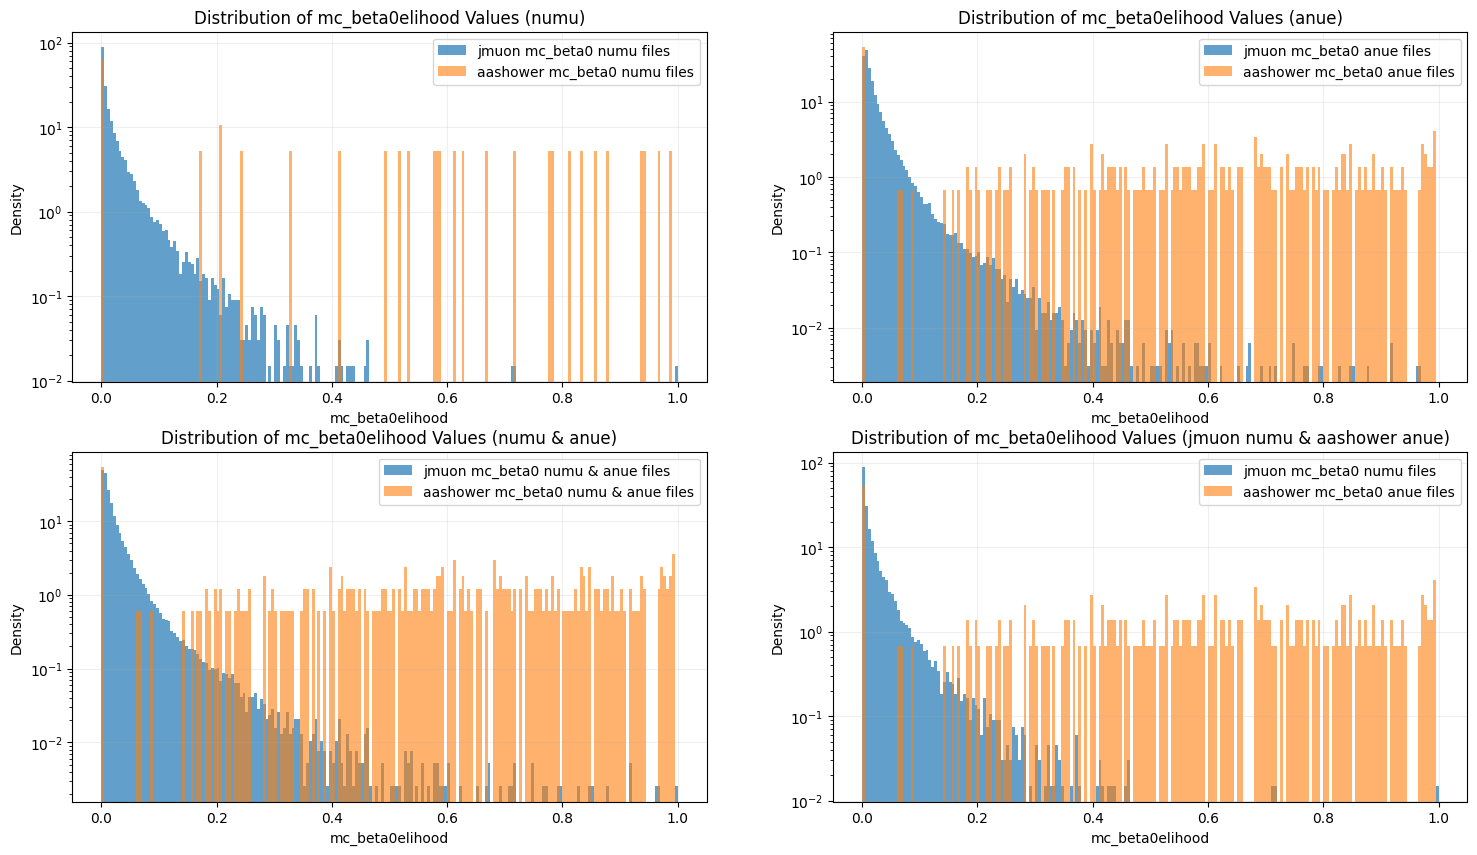

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
ax = axs[0][0]
ax.hist(t_all_mc_beta0_jm, bins=200, range=(0,1), alpha=0.7, label='jmuon mc_beta0 numu files', density=True, log = True)
ax.hist(t_all_mc_beta0_as, bins=200, range=(0,1), alpha=0.6, label='aashower mc_beta0 numu files', density=True, log=True)
ax.legend()
ax.set_xlabel('mc_beta0elihood')
ax.set_ylabel('Density')
ax.set_title('Distribution of mc_beta0elihood Values (numu)')
ax.grid(alpha=0.2)

ax = axs[0][1]
ax.hist(s_all_mc_beta0_jm, bins=200, range=(0,1), alpha=0.7, label='jmuon mc_beta0 anue files', density=True, log = True)
ax.hist(s_all_mc_beta0_as, bins=200, range=(0,1), alpha=0.6, label='aashower mc_beta0 anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('mc_beta0elihood')
ax.set_ylabel('Density')
ax.set_title('Distribution of mc_beta0elihood Values (anue)')
ax.grid(alpha=0.2)

ax = axs[1][0]
ax.hist(b_all_mc_beta0_jm, bins=200, range=(0,1), alpha=0.7, label='jmuon mc_beta0 numu & anue files', density=True, log = True)
ax.hist(b_all_mc_beta0_as, bins=200, range=(0,1), alpha=0.6, label='aashower mc_beta0 numu & anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('mc_beta0elihood')
ax.set_ylabel('Density')
ax.set_title('Distribution of mc_beta0elihood Values (numu & anue)')
ax.grid(alpha=0.2)

ax = axs[1][1]
ax.hist(t_all_mc_beta0_jm, bins=200, range=(0,1), alpha=0.7, label='jmuon mc_beta0 numu files', density=True, log = True)
ax.hist(s_all_mc_beta0_as, bins=200, range=(0,1), alpha=0.6, label='aashower mc_beta0 anue files', density=True, log=True)
ax.legend()
ax.set_xlabel('mc_beta0elihood')
ax.set_ylabel('Density')
ax.set_title('Distribution of mc_beta0elihood Values (jmuon numu & aashower anue)')
ax.grid(alpha=0.2)

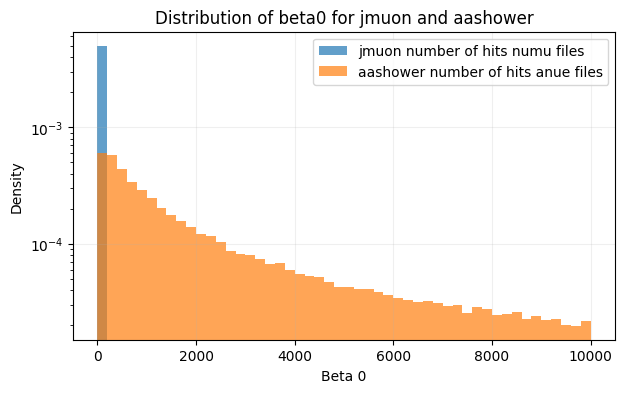

In [23]:
# Example of plotting the separations
plt.figure(figsize=(7, 4))
plt.hist(t_all_mc_beta0_jm, bins=50, range=(0,10000), alpha=0.7, label='jmuon number of hits numu files', density=True, log=True)
plt.hist(s_all_mc_beta0_as, bins=50, range=(0,10000), alpha=0.7, label='aashower number of hits anue files', density=True, log=True)
plt.legend()
plt.xlabel('Beta 0')
plt.ylabel('Density')
plt.title('Distribution of beta0 for jmuon and aashower')
plt.grid(alpha=0.2)
plt.show()

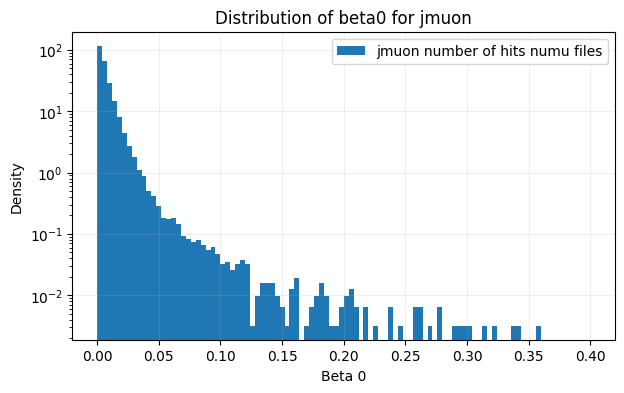

In [31]:
# Example of plotting the separations
plt.figure(figsize=(7, 4))
plt.hist(t_all_mc_beta0_jm, bins=100, range=(0,0.4), alpha=1, label='jmuon number of hits numu files', density=True, log=True)
#plt.hist(s_all_mc_beta0_as, bins=50, range=(0,10), alpha=0.5, label='aashower number of hits anue files', density=True, log=True)
plt.legend()
plt.xlabel('Beta 0')
plt.ylabel('Density')
plt.title('Distribution of beta0 for jmuon')
plt.grid(alpha=0.2)
plt.show()

E_as: [4923.23998673  505.67488794  342.40882811 ... 2027.35967099  786.9411751
   62.48968063]
E_jm: [5.63638109e+03 1.22519594e+02 4.84807161e+03 ... 1.86754868e+05
 1.54544430e+04 5.31252883e+02]
E_mc:  [1.10670567e+07 3.01949955e+02 2.82859124e+04 ... 1.11430656e+06
 1.08665581e+05 1.33754493e+04]


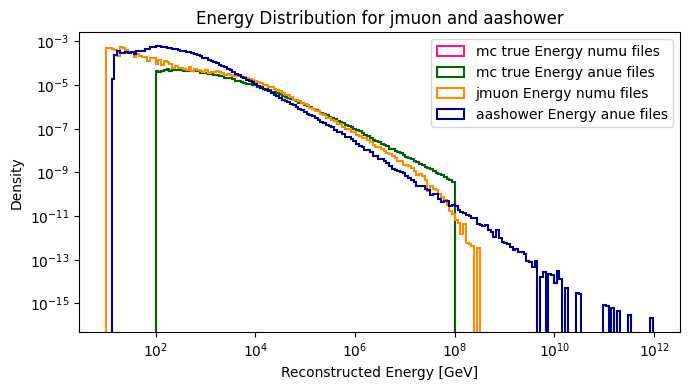

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl
import astropy.units as u

output_plot = "/home/hpc/capn/capn107h/software/psr/plots/arca_reco_energies_density_numu_files.png"

# Example input arrays
energy1 = t_all_E_as 
energy2 = t_all_E_jm 
energy3 = t_all_E_mc
energy4 = t_all_E_mc

def filter_energy(energy):
    if isinstance(energy, u.Quantity):
        return energy[energy > 1e1 * u.GeV]
    else:
        return energy[energy > 1e1]

valid_energy1 = filter_energy(energy1)
valid_energy2 = filter_energy(energy2)
valid_energy3 = filter_energy(energy3)
valid_energy4 = filter_energy(energy4)

if len(valid_energy1) == 0 or len(valid_energy2) == 0 or len(valid_energy3) == 0:
    raise ValueError("One of the energy arrays has no valid positive values.")

print("E_as:", valid_energy1)
print("E_jm:", valid_energy2)
print("E_mc: ", valid_energy3)

# Determine common bins based on combined range
min_log = np.log10(min(valid_energy1.min(), valid_energy2.min(), valid_energy3.min(), valid_energy4.min()))
max_log = np.log10(max(valid_energy1.max(), valid_energy2.max(), valid_energy3.max(), valid_energy4.max()))
logbins = np.logspace(min_log, max_log, 200)

# Plotting
plt.figure(figsize=(7, 4))
'''
plt.hist(
    [valid_energy1, valid_energy2, valid_energy3, valid_energy4],
    bins=logbins,
    log=True,
    label=["aashower Energy anue files", "jmuon Energy numu files", "mc true Energy anue files", "mc true Energy numu files"],
    color=["blue", "orange", "green", "deeppink"],
    histtype="stepfilled",
    alpha=0.5
)
'''
# Outline histograms

plt.hist(
    [valid_energy1, valid_energy2, valid_energy3, valid_energy4],
    bins=logbins,
    log=True,
    density = True,
    label=["aashower Energy anue files", "jmuon Energy numu files", "mc true Energy anue files", "mc true Energy numu files"],
    color=["darkblue", "darkorange", "darkgreen", "deeppink"],
    histtype="step",
    linewidth=1.5  # Thicker line for better visibility
)

pl.gca().set_xscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel("Density")
plt.title("ARCA: Energy Distribution (track files only)")
plt.legend()
plt.tight_layout()
#plt.grid(alpha=0.2)
plt.show()


E_as: [5.63638109e+03 1.22519594e+02 4.84807161e+03 ... 1.86754868e+05
 1.54544430e+04 5.31252883e+02]
E_jm: [  224.74124124 62216.51635368  1965.11820444 ...  1006.56758118
 96971.26876026 46941.81082474]
E_mc:  [1.10670567e+07 3.01949955e+02 2.82859124e+04 ... 1.11430656e+06
 1.08665581e+05 1.33754493e+04]


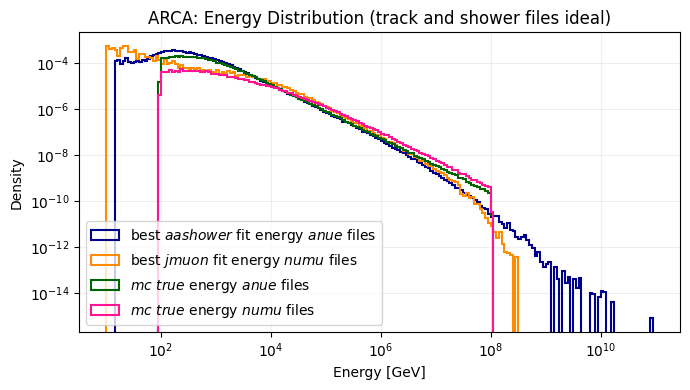

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl
import astropy.units as u

output_plot = "/home/hpc/capn/capn107h/software/psr/plots/arca_reco_energies_density_numu_and_anue_files_ideal.png"

# Example input arrays
energy1 = t_all_E_jm
energy2 = s_all_E_as
energy3 = t_all_E_mc
energy4 = s_all_E_mc

def filter_energy(energy):
    if isinstance(energy, u.Quantity):
        return energy[energy > 1e1 * u.GeV]
    else:
        return energy[energy > 1e1]

valid_energy1 = filter_energy(energy1)
valid_energy2 = filter_energy(energy2)
valid_energy3 = filter_energy(energy3)
valid_energy4 = filter_energy(energy4)

if len(valid_energy1) == 0 or len(valid_energy2) == 0 or len(valid_energy3) == 0:
    raise ValueError("One of the energy arrays has no valid positive values.")

print("E_as:", valid_energy1)
print("E_jm:", valid_energy2)
print("E_mc: ", valid_energy3)

# Determine common bins based on combined range
min_log = np.log10(min(valid_energy1.min(), valid_energy2.min(), valid_energy3.min(), valid_energy4.min()))
max_log = np.log10(max(valid_energy1.max(), valid_energy2.max(), valid_energy3.max(), valid_energy4.max()))
logbins = np.logspace(min_log, max_log, 200)

# Plotting
plt.figure(figsize=(7, 4))
'''
plt.hist(
    [valid_energy1, valid_energy2, valid_energy3, valid_energy4],
    bins=logbins,
    log=True,
    label=["aashower Energy anue files", "jmuon Energy numu files", "mc true Energy anue files", "mc true Energy numu files"],
    color=["blue", "orange", "green", "deeppink"],
    histtype="stepfilled",
    alpha=0.5
)
'''
# Outline histograms

plt.hist(
    [valid_energy3, valid_energy4, valid_energy1, valid_energy2],
    bins=logbins,
    log=True,
    density = True,
    label=[r"$\it{mc\ true}$ energy $\it{numu}$ files", r"$\it{mc\ true}$ energy $\it{anue}$ files", r"best $\it{jmuon}$ fit energy $\it{numu}$ files", r"best $\it{aashower}$ fit energy $\it{anue}$ files"],
    color=[  "deeppink", "darkgreen" ,"darkorange", "darkblue"],
    histtype="step",
    linewidth=1.5  # Thicker line for better visibility
)

pl.gca().set_xscale("log")
plt.xlabel("Energy [GeV]")
plt.ylabel("Density")
plt.title("ARCA: Energy Distribution (track and shower files ideal)")
plt.legend()
plt.tight_layout()
plt.grid(alpha=0.2)

plt.savefig(output_plot, bbox_inches="tight")
plt.show()

E_as: [  224.74124124 62216.51635368  1965.11820444 ...  1006.56758118
 96971.26876026 46941.81082474]
E_jm: [5.63638109e+03 1.22519594e+02 4.84807161e+03 ... 1.86754868e+05
 1.54544430e+04 5.31252883e+02]
E_mc:  [  2816.90776181  74722.07128124   1383.65789068 ...   6052.86531829
 208570.31077688  89157.37222045]


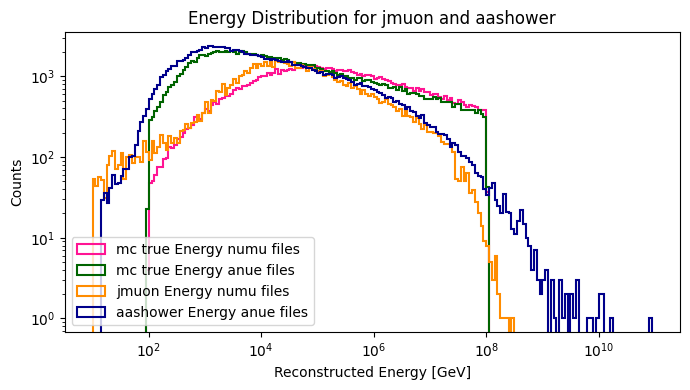

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl
import astropy.units as u

# Example input arrays
energy1 = s_all_E_as 
energy2 = t_all_E_jm 
energy3 = s_all_E_mc
energy4 = t_all_E_mc

def filter_energy(energy):
    if isinstance(energy, u.Quantity):
        return energy[energy > 1e1 * u.GeV]
    else:
        return energy[energy > 1e1]

valid_energy1 = filter_energy(energy1)
valid_energy2 = filter_energy(energy2)
valid_energy3 = filter_energy(energy3)
valid_energy4 = filter_energy(energy4)

if len(valid_energy1) == 0 or len(valid_energy2) == 0 or len(valid_energy3) == 0:
    raise ValueError("One of the energy arrays has no valid positive values.")

print("E_as:", valid_energy1)
print("E_jm:", valid_energy2)
print("E_mc: ", valid_energy3)

# Determine common bins based on combined range
min_log = np.log10(min(valid_energy1.min(), valid_energy2.min(), valid_energy3.min(), valid_energy4.min()))
max_log = np.log10(max(valid_energy1.max(), valid_energy2.max(), valid_energy3.max(), valid_energy4.max()))
logbins = np.logspace(min_log, max_log, 200)

# Plotting
plt.figure(figsize=(7, 4))
'''
plt.hist(
    [valid_energy1, valid_energy2, valid_energy3, valid_energy4],
    bins=logbins,
    log=True,
    label=["aashower Energy anue files", "jmuon Energy numu files", "mc true Energy anue files", "mc true Energy numu files"],
    color=["blue", "orange", "green", "deeppink"],
    histtype="stepfilled",
    alpha=0.5
)
'''
# Outline histograms

plt.hist(
    [valid_energy1, valid_energy2, valid_energy3, valid_energy4],
    bins=logbins,
    log=True,
    #density = True,
    label=["aashower Energy anue files", "jmuon Energy numu files", "mc true Energy anue files", "mc true Energy numu files"],
    color=["darkblue", "darkorange", "darkgreen", "deeppink"],
    histtype="step",
    linewidth=1.5  # Thicker line for better visibility
)

pl.gca().set_xscale("log")
plt.xlabel("Reconstructed Energy [GeV]")
plt.ylabel("Counts")
plt.title("Energy Distribution for jmuon and aashower")
plt.legend()
plt.tight_layout()
#plt.grid(alpha=0.2)
plt.show()


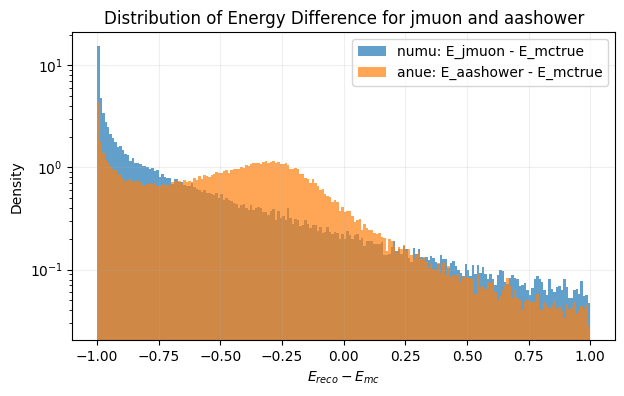

In [ ]:


plt.figure(figsize=(7, 4))
plt.hist(t_all_E_jm_diff, bins=200, range=(-1,1), alpha=0.7, label='numu: E_jmuon - E_mctrue', density=True,log=True)
plt.hist(s_all_E_as_diff, bins=200, range=(-1,1), alpha=0.7, label='anue: E_aashower - E_mctrue', density=True,log=True)
plt.legend()
plt.xlabel(r'$E_{reco}-E_{mc}$')
plt.ylabel('Density')
plt.title('Distribution of Energy Difference for jmuon and aashower')
plt.grid(alpha=0.2)
plt.show()

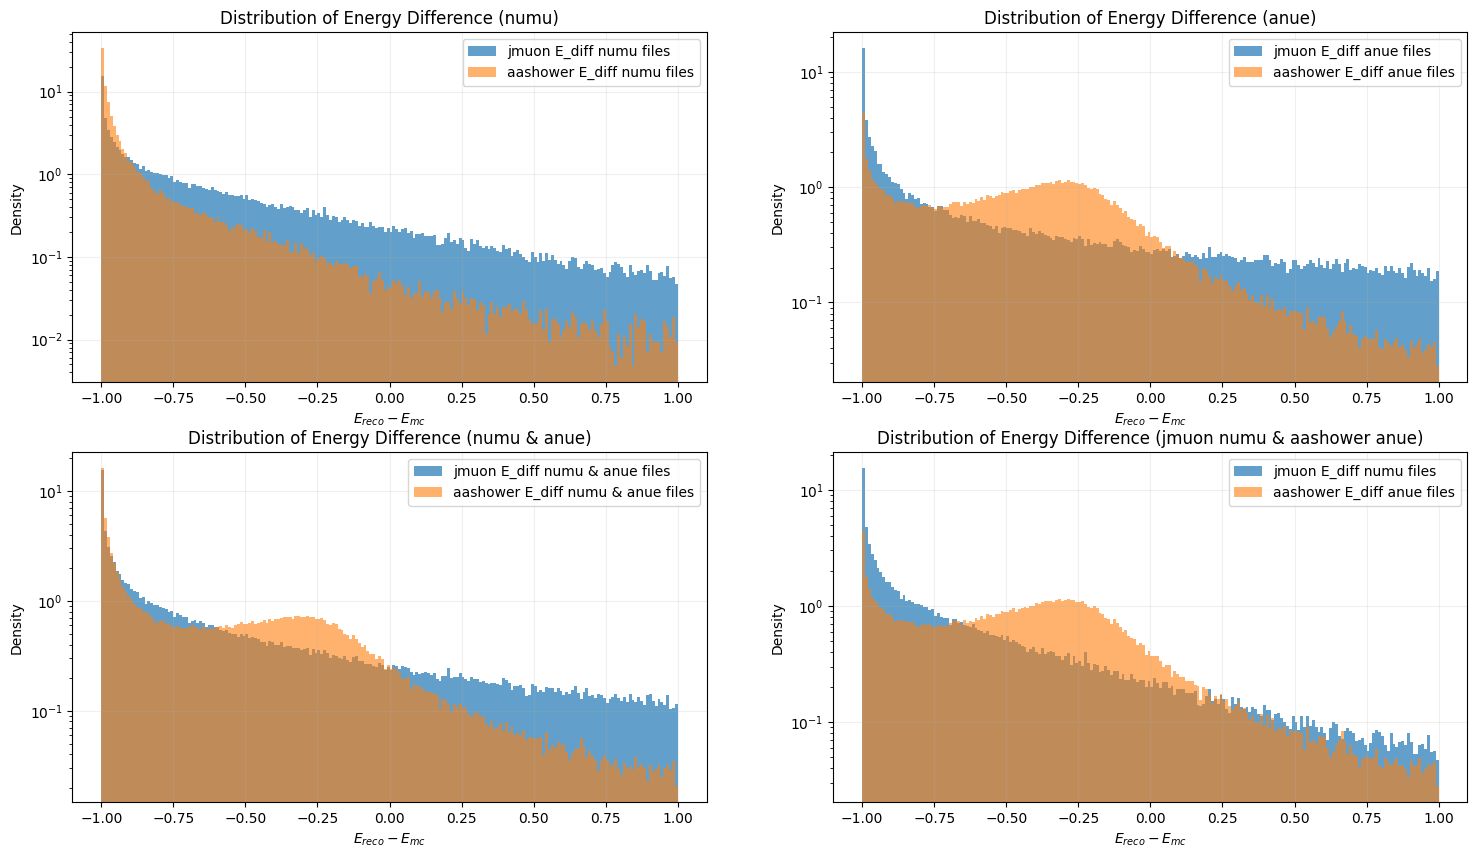

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(18, 10))
ax = axs[0][0]
ax.hist(t_all_E_jm_diff, bins=200, range=(-1,1), alpha=0.7, label='jmuon E_diff numu files', density=True, log = True)
ax.hist(t_all_E_as_diff, bins=200, range=(-1,1), alpha=0.6, label='aashower E_diff numu files', density=True, log=True)
ax.legend()
ax.set_xlabel(r'$E_{reco}-E_{mc}$')
ax.set_ylabel('Density')
ax.set_title('Distribution of Energy Difference (numu)')
ax.grid(alpha=0.2)

ax = axs[0][1]
ax.hist(s_all_E_jm_diff, bins=200, range=(-1,1), alpha=0.7, label='jmuon E_diff anue files', density=True, log = True)
ax.hist(s_all_E_as_diff, bins=200, range=(-1,1), alpha=0.6, label='aashower E_diff anue files', density=True, log=True)
ax.legend()
ax.set_xlabel(r'$E_{reco}-E_{mc}$')
ax.set_ylabel('Density')
ax.set_title('Distribution of Energy Difference (anue)')
ax.grid(alpha=0.2)

ax = axs[1][0]
ax.hist(b_all_E_jm_diff, bins=200, range=(-1,1), alpha=0.7, label='jmuon E_diff numu & anue files', density=True, log = True)
ax.hist(b_all_E_as_diff, bins=200, range=(-1,1), alpha=0.6, label='aashower E_diff numu & anue files', density=True, log=True)
ax.legend()
ax.set_xlabel(r'$E_{reco}-E_{mc}$')
ax.set_ylabel('Density')
ax.set_title('Distribution of Energy Difference (numu & anue)')
ax.grid(alpha=0.2)

ax = axs[1][1]
ax.hist(t_all_E_jm_diff, bins=200, range=(-1,1), alpha=0.7, label='jmuon E_diff numu files', density=True, log = True)
ax.hist(s_all_E_as_diff, bins=200, range=(-1,1), alpha=0.6, label='aashower E_diff anue files', density=True, log=True)
ax.legend()
ax.set_xlabel(r'$E_{reco}-E_{mc}$')
ax.set_ylabel('Density')
ax.set_title('Distribution of Energy Difference (jmuon numu & aashower anue)')
ax.grid(alpha=0.2)

E_as: [5.81460314e+02 1.65709436e+02 2.01370088e+02 ... 6.84178992e+01
 8.40704212e+02 7.11366056e+07]
E_jm: [   539.8816543    4586.76161968   1290.25488627 ... 357620.69648792
  11773.40188995   2345.65257875]


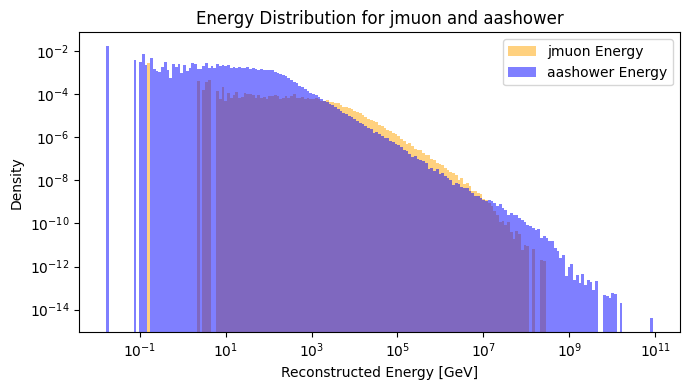

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import pylab as pl
import astropy.units as u

# Example input arrays
energy1 = s_all_E_as_diff  
energy2 = t_all_E_jm_diff 

def filter_energy(energy):
    if isinstance(energy, u.Quantity):
        return energy[energy > 0* u.GeV]
    else:
        return energy[energy > 0]

valid_energy1 = filter_energy(energy1)
valid_energy2 = filter_energy(energy2)

if len(valid_energy1) == 0 or len(valid_energy2) == 0:
    raise ValueError("One of the energy arrays has no valid positive values.")

print("E_as:", valid_energy1)
print("E_jm:", valid_energy2)

# Determine common bins based on combined range
min_log = np.log10(min(valid_energy1.min(), valid_energy2.min()))
max_log = np.log10(max(valid_energy1.max(), valid_energy2.max()))
logbins = np.logspace(min_log, max_log, 200)

# Plotting
plt.figure(figsize=(7, 4))

plt.hist(
    [valid_energy1, valid_energy2],
    bins=logbins,
    log=True,
    density = True,
    label=["aashower Energy", "jmuon Energy"],
    color=["blue", "orange"],
    histtype="stepfilled",
    alpha=0.5
)

# Outline histograms
'''
plt.hist(
    [valid_energy1, valid_energy2, valid_energy3],
    bins=logbins,
    log=True,
    color=["darkblue", "darkorange", "darkgreen"],
    histtype="step",
    linewidth=1.5  # Thicker line for better visibility
)
'''
pl.gca().set_xscale("log")
plt.xlabel("Reconstructed Energy [GeV]")
plt.ylabel("Density")
plt.title("Energy Distribution for jmuon and aashower")
plt.legend()
plt.tight_layout()
#plt.grid(alpha=0.2)
plt.show()

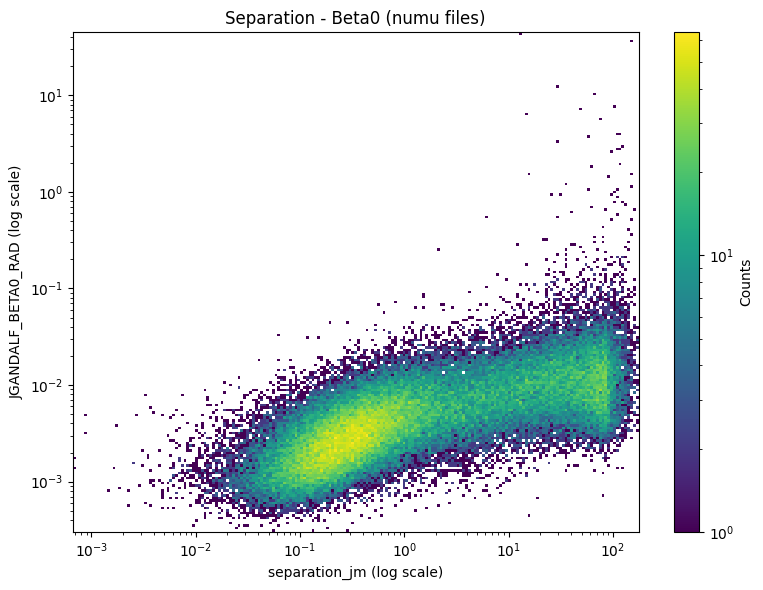

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

#all_separation_jm = np.concatenate(separation_jm_list)
#all_separation_as = np.concatenate(separation_as_list)
#all_mc_beta0_jm_list = np.concatenate(mc_beta0_jm_list)
#all_mc_beta0_as_list = np.concatenate(mc_beta0_as_list)
#all_nhits_jm_list = np.concatenate(nhits_jm_list)
#all_nhits_as_list = np.concatenate(nhits_as_list)

# Convert awkward arrays to numpy arrays
x = np.asarray(t_all_separation_jm)
#y = np.asarray(mc_beta0_jm[mc_mask_jm])

#x = np.asarray(separation_as.value)
#y = np.asarray(mc_beta0_as[mc_mask_as])

y = np.asarray(t_all_mc_beta0_jm)
#y = np.asarray(nhits_as[mc_mask_as])

# Filter out non-positive values
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Define log-spaced bins
x_bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
y_bins = np.logspace(np.log10(y.min()), np.log10(y.max()), 200)

# Create 2D histogram
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=[x_bins, y_bins], norm=colors.LogNorm())

# Set log scale on both axes
plt.xscale('log')
plt.yscale('log')

# Labels and colorbar
plt.title("Separation - Beta0 (numu files)")
plt.xlabel('separation_jm (log scale)')
plt.ylabel('JGANDALF_BETA0_RAD (log scale)')
plt.colorbar(label='Counts')
plt.tight_layout()
plt.show()


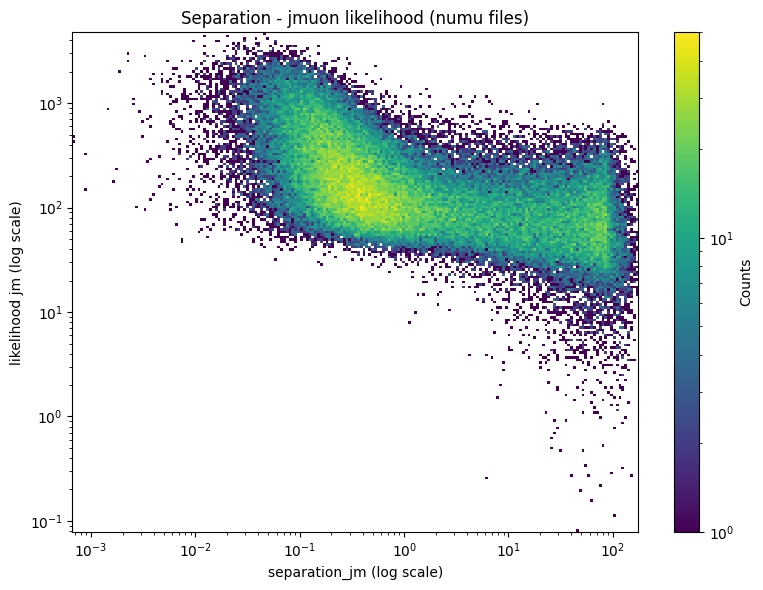

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors


x = np.asarray(t_all_separation_jm)


y = np.asarray(t_all_lik_jm)


# Filter out non-positive values
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Define log-spaced bins
x_bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
y_bins = np.logspace(np.log10(y.min()), np.log10(y.max()), 200)

# Create 2D histogram
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=[x_bins, y_bins], norm=colors.LogNorm())

# Set log scale on both axes
plt.xscale('log')
plt.yscale('log')

# Labels and colorbar
plt.title("Separation - jmuon likelihood (numu files)")
plt.xlabel('separation_jm (log scale)')
plt.ylabel('likelihood jm (log scale)')
plt.colorbar(label='Counts')
plt.tight_layout()
plt.show()


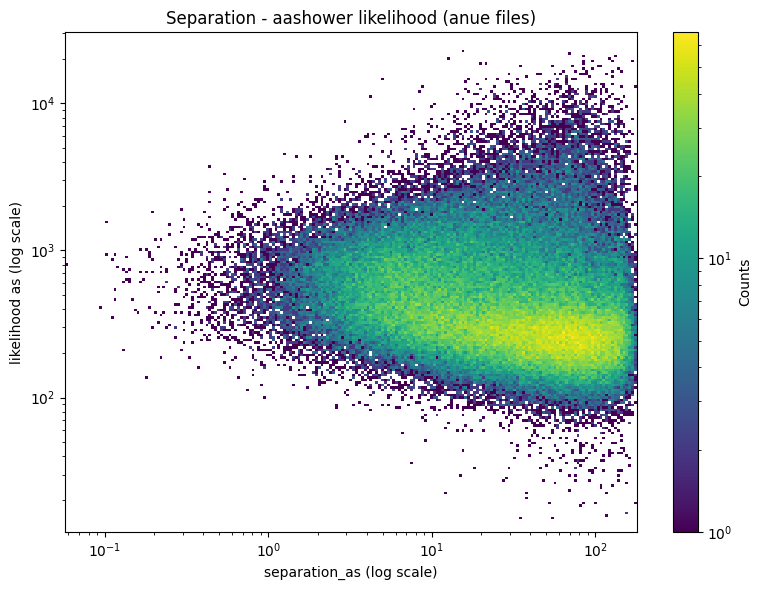

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors



# Convert awkward arrays to numpy arrays
x = np.asarray(s_all_separation_as)

y = np.asarray(-s_all_lik_as)


# Filter out non-positive values
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Define log-spaced bins
x_bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
y_bins = np.logspace(np.log10(y.min()), np.log10(y.max()), 200)

# Create 2D histogram
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=[x_bins, y_bins], norm=colors.LogNorm())

# Set log scale on both axes
plt.xscale('log')
plt.yscale('log')

# Labels and colorbar
plt.title("Separation - aashower likelihood (anue files)")
plt.xlabel('separation_as (log scale)')
plt.ylabel('likelihood as (log scale)')
plt.colorbar(label='Counts')
plt.tight_layout()
plt.show()


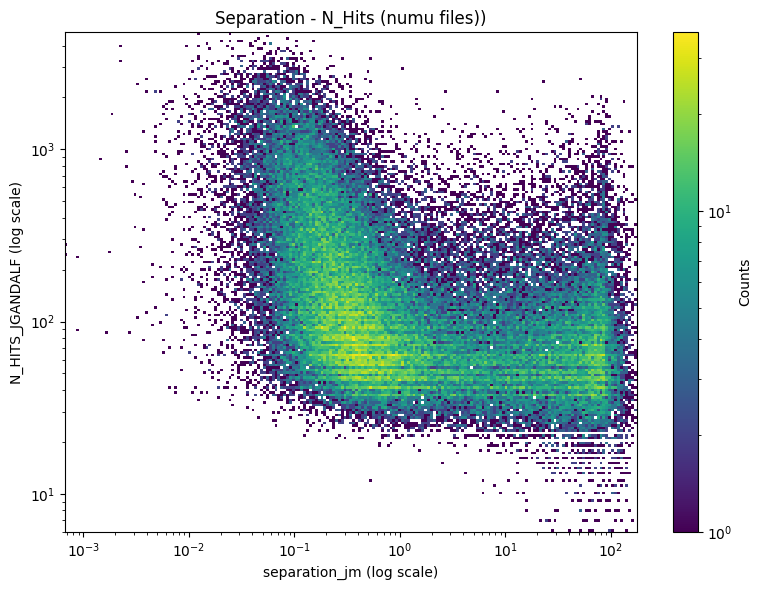

In [53]:
x = np.asarray(t_all_separation_jm)
y = np.asarray(t_all_nhits_jm)


# Filter out non-positive values
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Define log-spaced bins
x_bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
y_bins = np.logspace(np.log10(y.min()), np.log10(y.max()), 200)

# Create 2D histogram
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=[x_bins, y_bins], norm=colors.LogNorm())

# Set log scale on both axes
plt.xscale('log')
plt.yscale('log')

# Labels and colorbar
plt.title("Separation - N_Hits (numu files))")
plt.xlabel('separation_jm (log scale)')
plt.ylabel('N_HITS_JGANDALF (log scale)')
plt.colorbar(label='Counts')
plt.tight_layout()
plt.show()


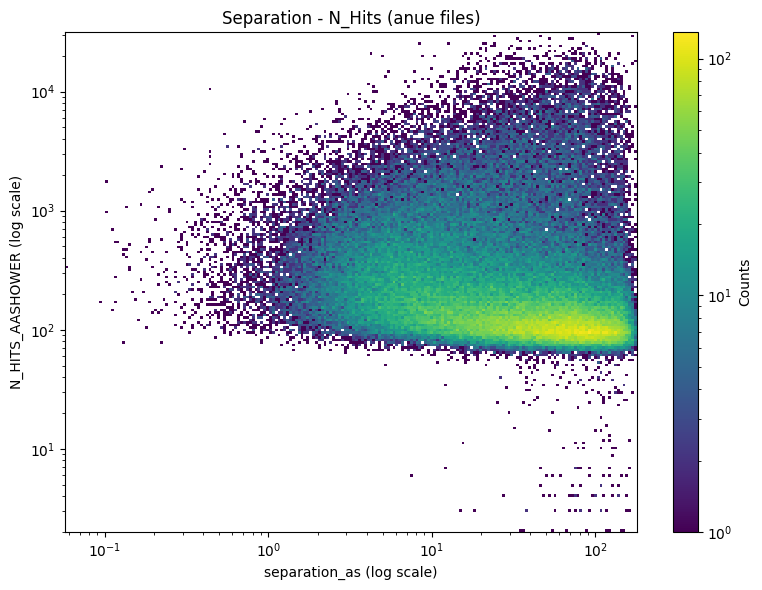

In [54]:
x = np.asarray(s_all_separation_as)
y = np.asarray(s_all_nhits_as)


# Filter out non-positive values
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Define log-spaced bins
x_bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
y_bins = np.logspace(np.log10(y.min()), np.log10(y.max()), 200)

# Create 2D histogram
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=[x_bins, y_bins], norm=colors.LogNorm())

# Set log scale on both axes
plt.xscale('log')
plt.yscale('log')

# Labels and colorbar
plt.title("Separation - N_Hits (anue files)")
plt.xlabel('separation_as (log scale)')
plt.ylabel('N_HITS_AASHOWER (log scale)')
plt.colorbar(label='Counts')
plt.tight_layout()
plt.show()


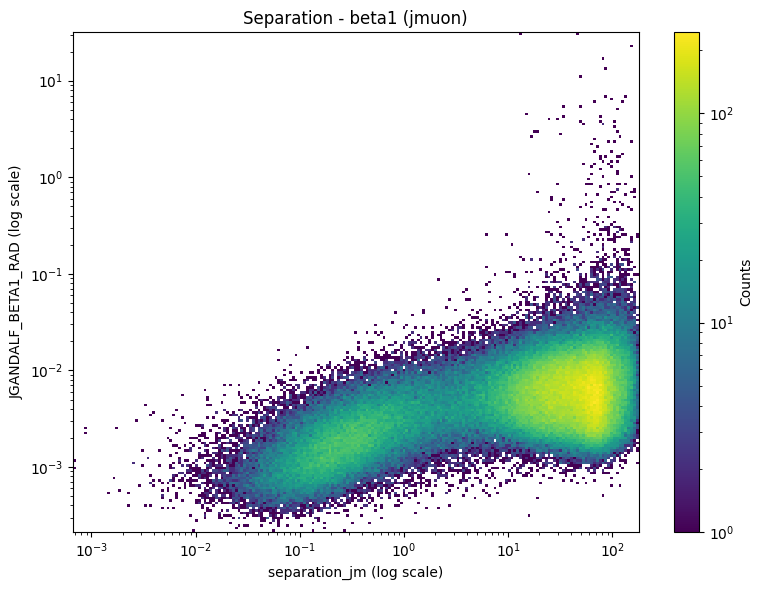

In [97]:
x = np.asarray(all_separation_jm)
y = np.asarray(all_mc_beta1_jm)


# Filter out non-positive values
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Define log-spaced bins
x_bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
y_bins = np.logspace(np.log10(y.min()), np.log10(y.max()), 200)

# Create 2D histogram
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=[x_bins, y_bins], norm=colors.LogNorm())

# Set log scale on both axes
plt.xscale('log')
plt.yscale('log')

# Labels and colorbar
plt.title("Separation - beta1 (jmuon)")
plt.xlabel('separation_jm (log scale)')
plt.ylabel('JGANDALF_BETA1_RAD (log scale)')
plt.colorbar(label='Counts')
plt.tight_layout()
plt.show()

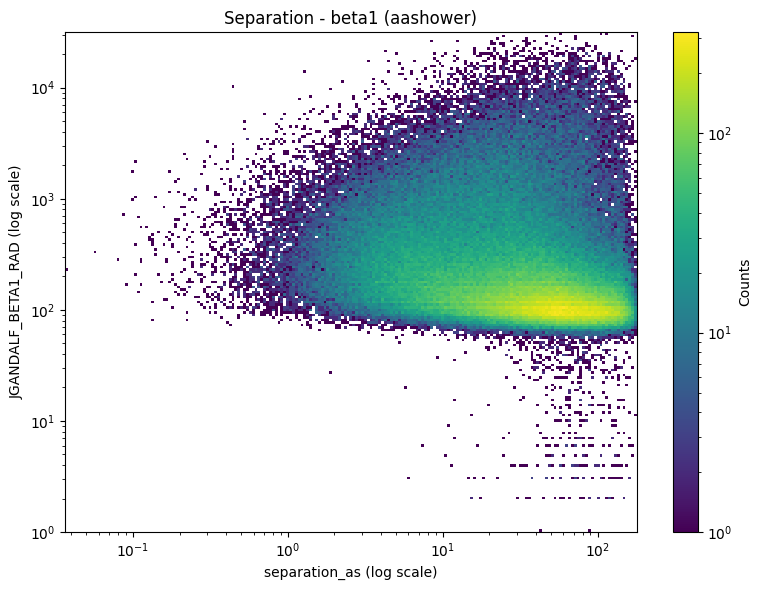

In [98]:
x = np.asarray(all_separation_as)
y = np.asarray(all_mc_beta1_as)


# Filter out non-positive values
mask = (x > 0) & (y > 0)
x = x[mask]
y = y[mask]

# Define log-spaced bins
x_bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
y_bins = np.logspace(np.log10(y.min()), np.log10(y.max()), 200)

# Create 2D histogram
plt.figure(figsize=(8, 6))
plt.hist2d(x, y, bins=[x_bins, y_bins], norm=colors.LogNorm())

# Set log scale on both axes
plt.xscale('log')
plt.yscale('log')

# Labels and colorbar
plt.title("Separation - beta1 (aashower)")
plt.xlabel('separation_as (log scale)')
plt.ylabel('JGANDALF_BETA1_RAD (log scale)')
plt.colorbar(label='Counts')
plt.tight_layout()
plt.show()

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

def plot_multiple_hist2d(datasets):
    """
    Plots multiple 2D histograms in a 2x2 grid with log-log axes.

    Parameters:
    - datasets: List of dictionaries with keys:
        - 'x': array-like, x values
        - 'y': array-like, y values
        - 'title': string, plot title
        - 'xlabel': string, x-axis label
        - 'ylabel': string, y-axis label
        - 'y_transform': function (optional), transformation to apply to y (e.g., np.negative)
    """
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))

    for i, data in enumerate(datasets):
        ax = axs[i // 2][i % 2]

        x = np.asarray(data['x'])
        y = np.asarray(data['y'])
        if 'y_transform' in data:
            y = data['y_transform'](y)

        # Filter out non-positive values
        mask = (x > 0) & (y > 0)
        x = x[mask]
        y = y[mask]

        # Define log-spaced bins
        x_bins = np.logspace(np.log10(x.min()), np.log10(x.max()), 200)
        y_bins = np.logspace(np.log10(y.min()), np.log10(y.max()), 200)

        # Plot
        h = ax.hist2d(x, y, bins=[x_bins, y_bins], norm=colors.LogNorm())
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_title(data['title'])
        ax.set_xlabel(f"{data['xlabel']} (log scale)")
        ax.set_ylabel(f"{data['ylabel']} (log scale)")
        fig.colorbar(h[3], ax=ax, label='Counts')

        if 'y_lim' in data:
            ax.set_ylim(data['y_lim'])
        if 'x_lim' in data:
            ax.set_xlim(data['x_lim'])


        ax.grid()

    plt.tight_layout()
    plt.show()


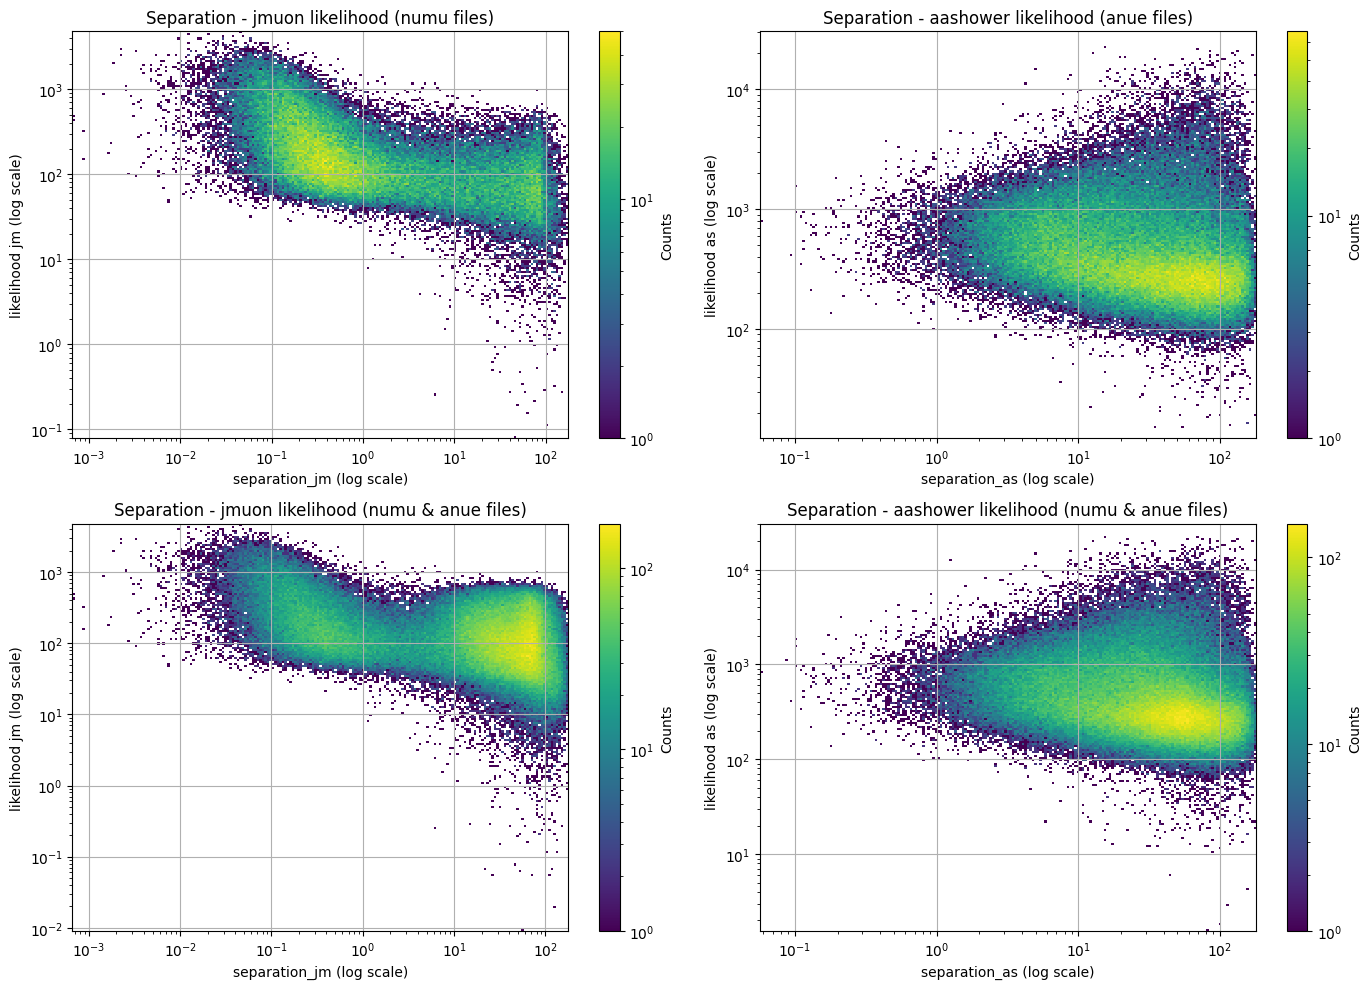

In [16]:
datasets = [
    {
        'x': t_all_separation_jm,
        'y': t_all_lik_jm,
        'title': 'Separation - jmuon likelihood (numu files)',
        'xlabel': 'separation_jm',
        'ylabel': 'likelihood jm'
    },
    {
        'x': s_all_separation_as,
        'y': s_all_lik_as,
        'y_transform': np.negative,
        'title': 'Separation - aashower likelihood (anue files)',
        'xlabel': 'separation_as',
        'ylabel': 'likelihood as'
    },
    {
        'x': b_all_separation_jm,
        'y': b_all_lik_jm,
        'title': 'Separation - jmuon likelihood (numu & anue files)',
        'xlabel': 'separation_jm',
        'ylabel': 'likelihood jm'
    },
    {
        'x': b_all_separation_as,
        'y': b_all_lik_as,
        'y_transform': np.negative,
        'title': 'Separation - aashower likelihood (numu & anue files)',
        'xlabel': 'separation_as',
        'ylabel': 'likelihood as'
    }
]

plot_multiple_hist2d(datasets)


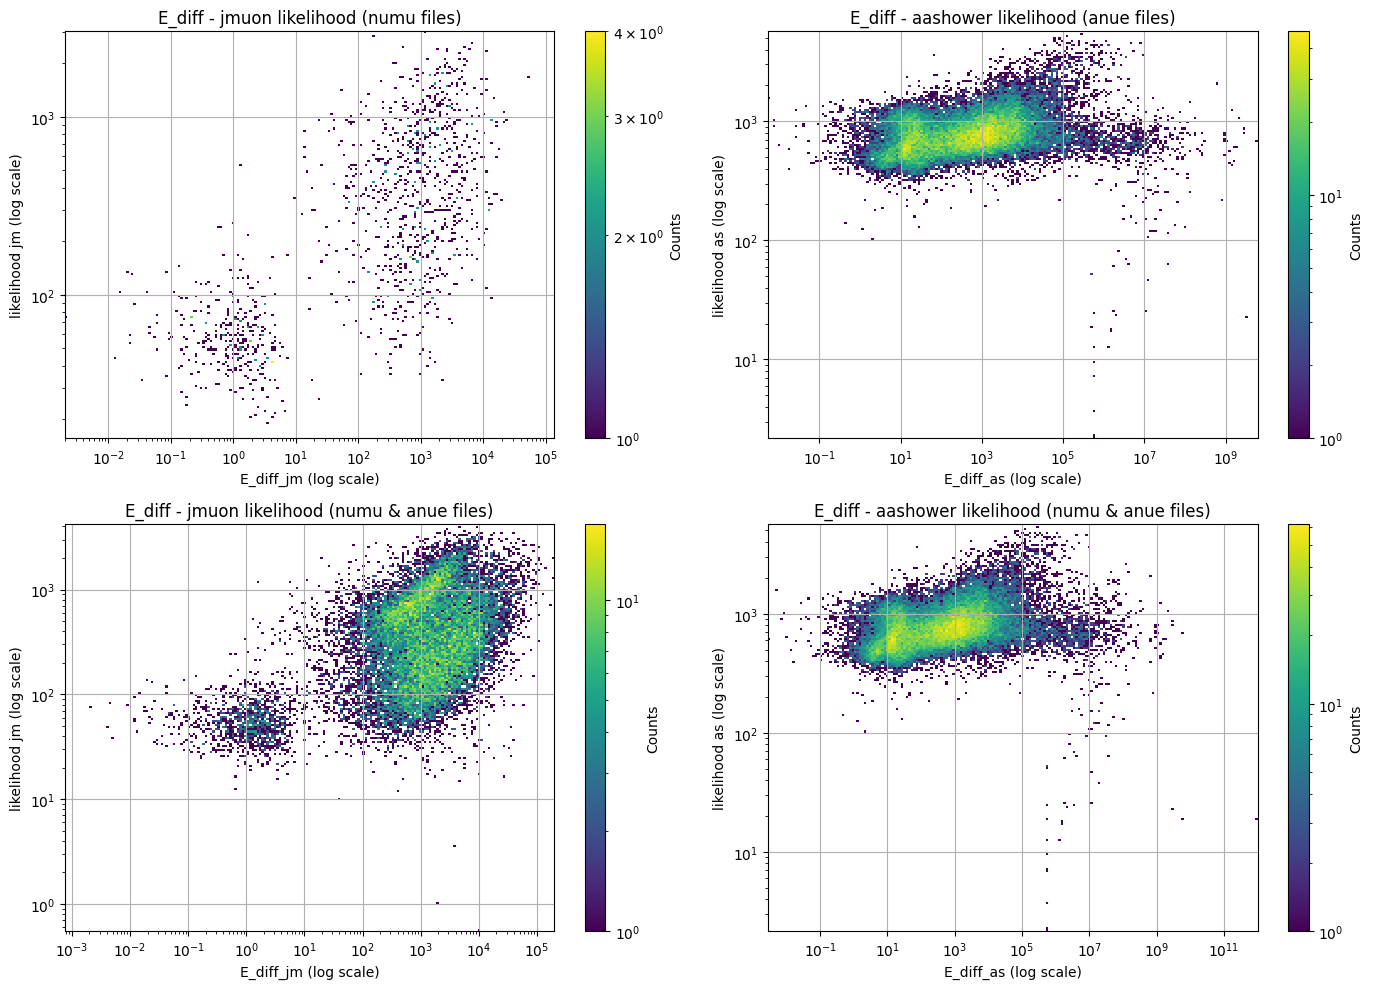

In [43]:
datasets = [
    {
        'x': t_all_E_jm_diff,
        'y': t_all_lik_jm,
        'title': 'E_diff - jmuon likelihood (numu files)',
        'xlabel': 'E_diff_jm',
        'ylabel': 'likelihood jm'
    },
    {
        'x': s_all_E_as_diff,
        'y': s_all_lik_as,
        'y_transform': np.negative,
        'title': 'E_diff - aashower likelihood (anue files)',
        'xlabel': 'E_diff_as',
        'ylabel': 'likelihood as'
    },
    {
        'x': b_all_E_jm_diff,
        'y': b_all_lik_jm,
        'title': 'E_diff - jmuon likelihood (numu & anue files)',
        'xlabel': 'E_diff_jm',
        'ylabel': 'likelihood jm'
    },
    {
        'x': b_all_E_as_diff,
        'y': b_all_lik_as,
        'y_transform': np.negative,
        'title': 'E_diff - aashower likelihood (numu & anue files)',
        'xlabel': 'E_diff_as',
        'ylabel': 'likelihood as'
    }
]

plot_multiple_hist2d(datasets)


In [44]:
print(s_all_separation_as)
print(t_all_separation_jm)

[  0.66263369  13.33375962  81.69408598 ...   4.1729747  102.94612862
  85.6395963 ]
[71.03971569 36.91004304 33.58262002 ... 15.73922106  1.58123993
 77.37088252]


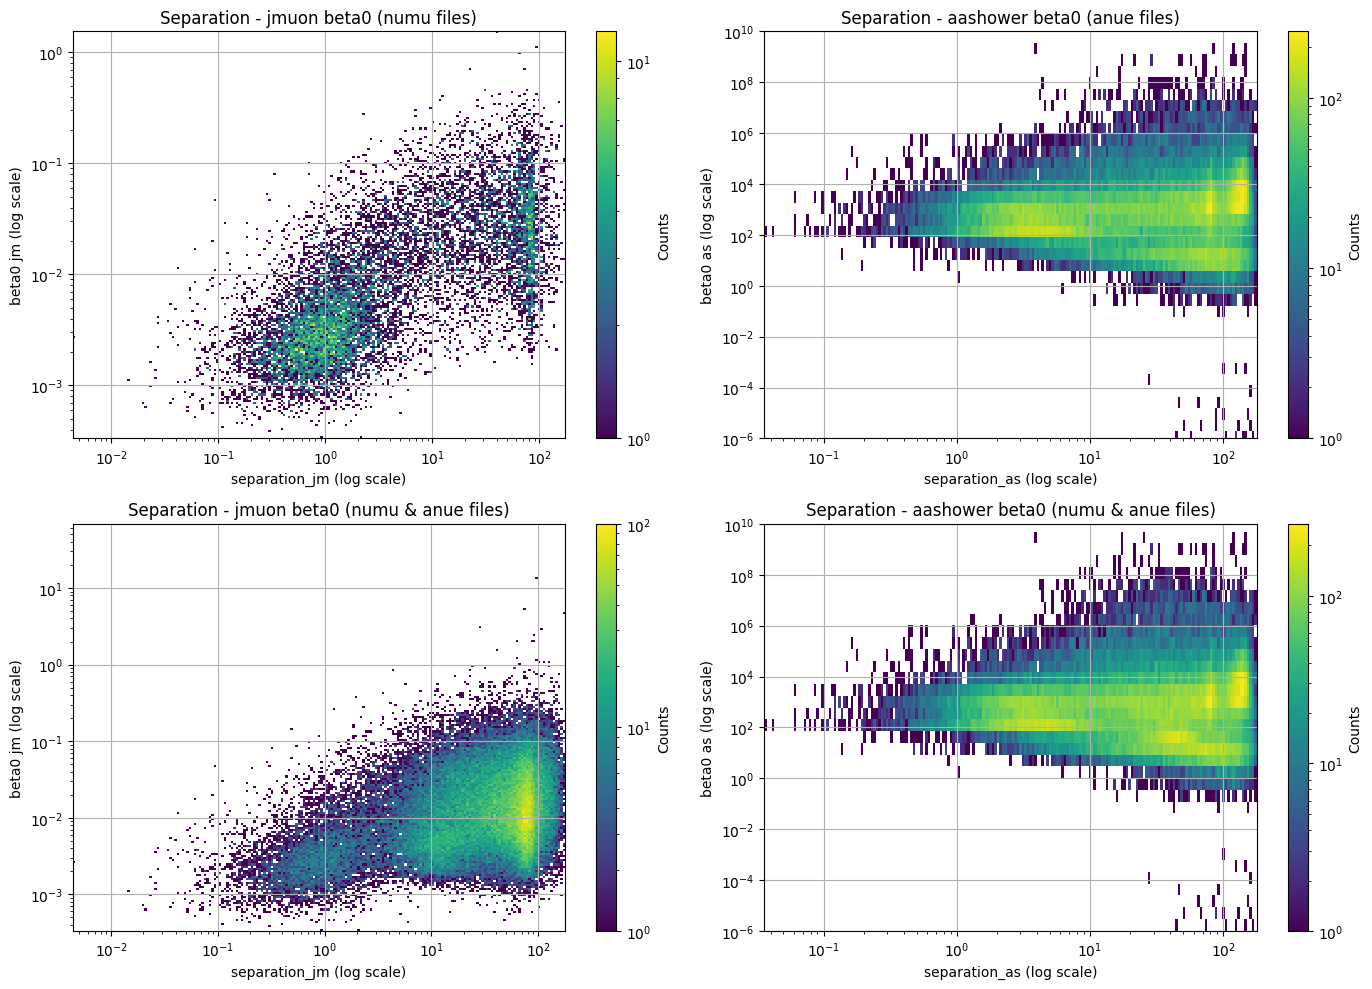

In [49]:
datasets = [
    {
        'x': t_all_separation_jm,
        'y': t_all_mc_beta0_jm,
        'title': 'Separation - jmuon beta0 (numu files)',
        'xlabel': 'separation_jm',
        'ylabel': 'beta0 jm'
    },
    {
        'x': s_all_separation_as,
        'y': s_all_mc_beta0_as,
        'title': 'Separation - aashower beta0 (anue files)',
        'xlabel': 'separation_as',
        'ylabel': 'beta0 as',
        'y_lim' : [1e-6,1e10]
    },
    {
        'x': b_all_separation_jm,
        'y': b_all_mc_beta0_jm,
        'title': 'Separation - jmuon beta0 (numu & anue files)',
        'xlabel': 'separation_jm',
        'ylabel': 'beta0 jm'
    },
    {
        'x': b_all_separation_as,
        'y': b_all_mc_beta0_as,
        'title': 'Separation - aashower beta0 (numu & anue files)',
        'xlabel': 'separation_as',
        'ylabel': 'beta0 as',
        'y_lim' : [1e-6,1e10]
    }
]

plot_multiple_hist2d(datasets)

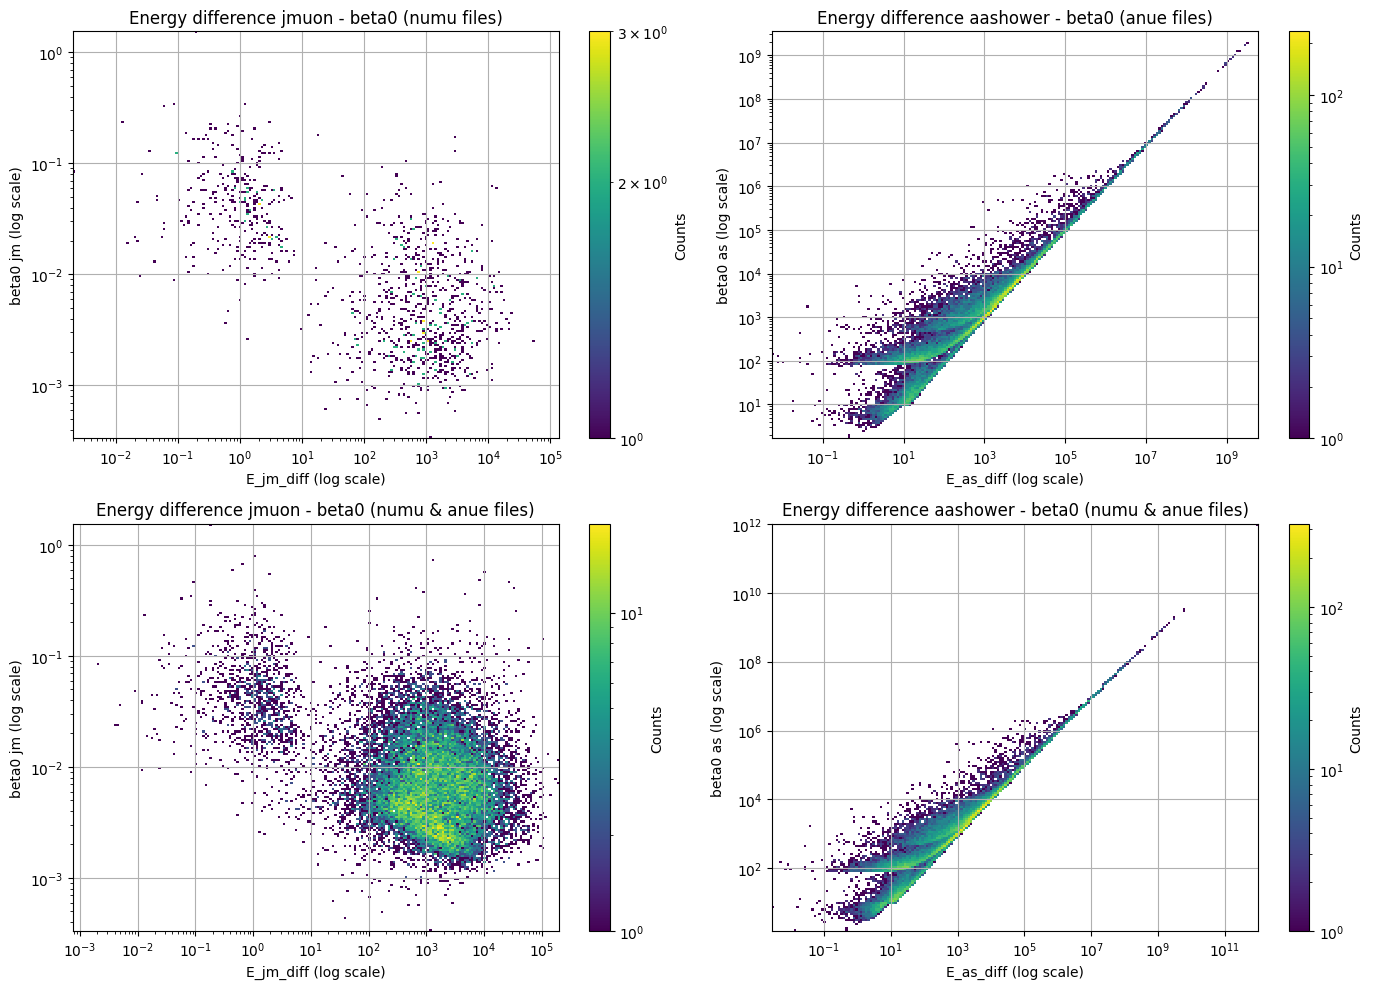

In [50]:
datasets = [
    {
        'x': t_all_E_jm_diff,
        'y': t_all_mc_beta0_jm,
        'title': 'Energy difference jmuon - beta0 (numu files)',
        'xlabel': 'E_jm_diff',
        'ylabel': 'beta0 jm'
    },
    {
        'x': s_all_E_as_diff,
        'y': s_all_mc_beta0_as,
        'title': 'Energy difference aashower - beta0 (anue files)',
        'xlabel': 'E_as_diff',
        'ylabel': 'beta0 as' },
    {
        'x': b_all_E_jm_diff,
        'y': b_all_mc_beta0_jm,
        'title': 'Energy difference jmuon - beta0 (numu & anue files)',
        'xlabel': 'E_jm_diff',
        'ylabel': 'beta0 jm'
    },
    {
        'x': b_all_E_as_diff,
        'y': b_all_mc_beta0_as,
        'title': 'Energy difference aashower - beta0 (numu & anue files)',
        'xlabel': 'E_as_diff',
        'ylabel': 'beta0 as' }
]

plot_multiple_hist2d(datasets)

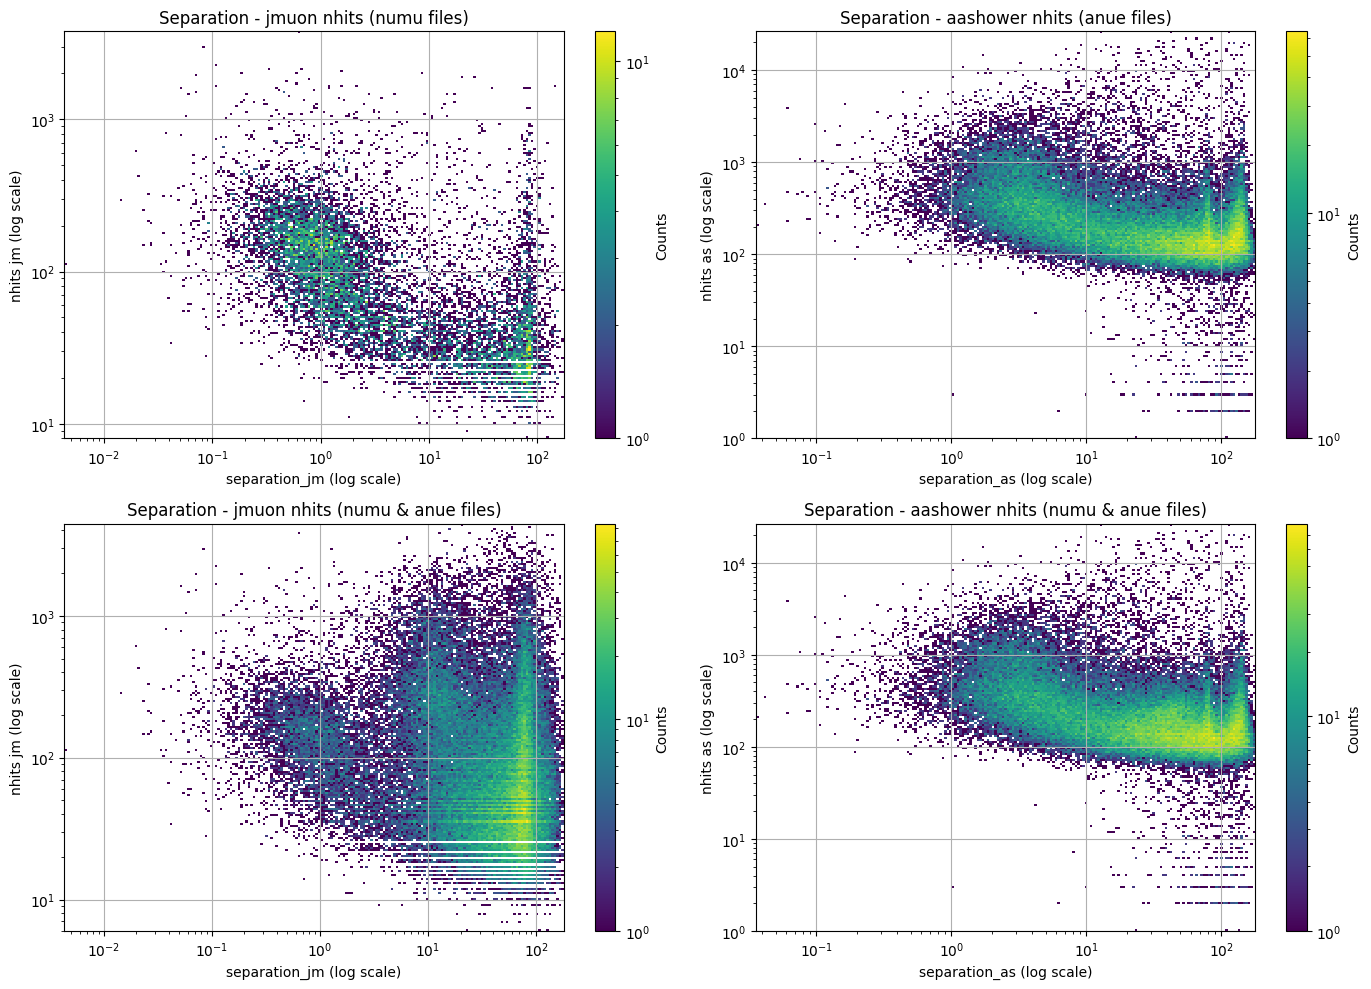

In [51]:
datasets = [
    {
        'x': t_all_separation_jm,
        'y': t_all_nhits_jm,
        'title': 'Separation - jmuon nhits (numu files)',
        'xlabel': 'separation_jm',
        'ylabel': 'nhits jm'
    },
    {
        'x': s_all_separation_as,
        'y': s_all_nhits_as,
        'title': 'Separation - aashower nhits (anue files)',
        'xlabel': 'separation_as',
        'ylabel': 'nhits as'
    },
    {
        'x': b_all_separation_jm,
        'y': b_all_nhits_jm,
        'title': 'Separation - jmuon nhits (numu & anue files)',
        'xlabel': 'separation_jm',
        'ylabel': 'nhits jm'
    },
    {
        'x': b_all_separation_as,
        'y': b_all_nhits_as,
        'title': 'Separation - aashower nhits (numu & anue files)',
        'xlabel': 'separation_as',
        'ylabel': 'nhits as'
    }
]

plot_multiple_hist2d(datasets)

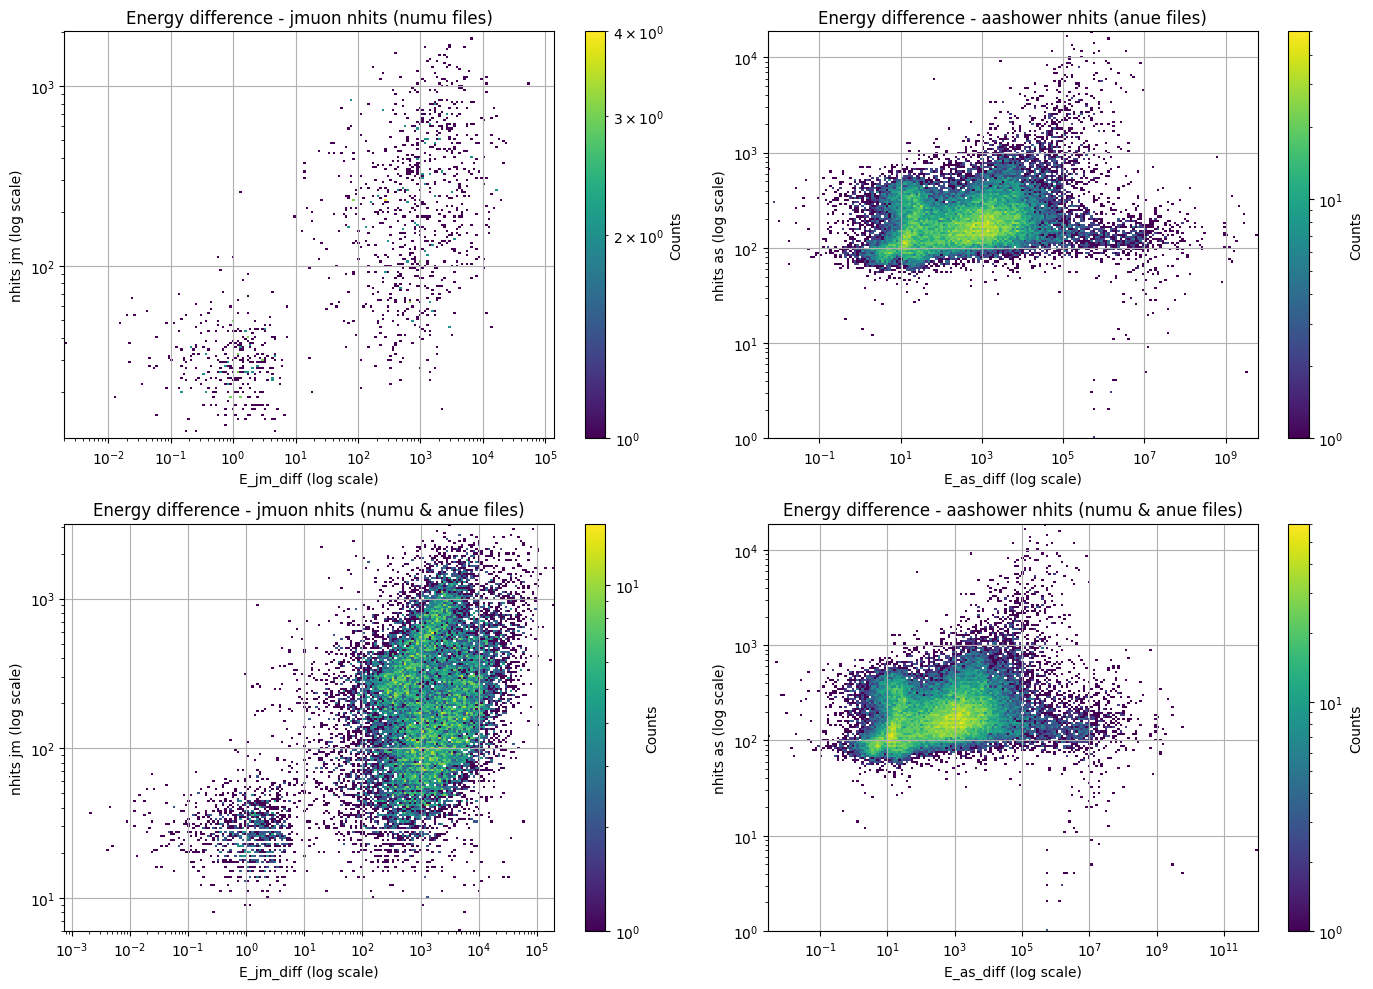

In [52]:
datasets = [
    {
        'x': t_all_E_jm_diff,
        'y': t_all_nhits_jm,
        'title': 'Energy difference - jmuon nhits (numu files)',
        'xlabel': 'E_jm_diff',
        'ylabel': 'nhits jm'
    },
    {
        'x': s_all_E_as_diff,
        'y': s_all_nhits_as,
        'title': 'Energy difference - aashower nhits (anue files)',
        'xlabel': 'E_as_diff',
        'ylabel': 'nhits as'
    },
    {
        'x': b_all_E_jm_diff,
        'y': b_all_nhits_jm,
        'title': 'Energy difference - jmuon nhits (numu & anue files)',
        'xlabel': 'E_jm_diff',
        'ylabel': 'nhits jm'
    },
    {
        'x': b_all_E_as_diff,
        'y': b_all_nhits_as,
        'title': 'Energy difference - aashower nhits (numu & anue files)',
        'xlabel': 'E_as_diff',
        'ylabel': 'nhits as'
    }
]

plot_multiple_hist2d(datasets)

# Data Files

In [3]:
from km3io import OfflineReader, tools
from km3astro.coord import local_event
import numpy as np
from km3astro.io import root_to_hdf5, load_hdf5_tables
import os
import matplotlib.pyplot as plt
from km3io.tools import fitinf
import km3io.definitions as kd
from astropy.time import Time

def dir_to_spherical(tracks):
    """
    Convert directional coordinates (x, y, z) to spherical coordinates (theta, phi).
    """
    vec = np.array([tracks.dir_x, tracks.dir_y, tracks.dir_z])
    vec = np.transpose(vec)
    theta_val = tools.theta(vec)
    phi_val = tools.phi(vec)
    return theta_val, phi_val

def get_utc_timeslice(OfflineObject):
    """
    Calculate UTC time of the timeslices where the events were put based on input data.
    """
    sec = OfflineObject.t_sec
    tns = OfflineObject.t_ns
    S_TO_NS = np.uint64(1e9)
    times = sec + tns / S_TO_NS  # Combine seconds and nanoseconds to get time in seconds
    astropy_times = Time(sec, tns / S_TO_NS, format="unix")
    return times, astropy_times

def get_utc_tracktime(timeslice, tracktimes):
    """
    Calculate UTC time of the track times based on timeslices and track times.
    """
    S_TO_NS = np.uint64(1e9)
    times = timeslice + tracktimes / S_TO_NS  # Combine seconds and nanoseconds to get time in seconds
    astropy_times = Time(timeslice, tracktimes / S_TO_NS, format="unix")
    return times, astropy_times


def load_and_combine_data(file_list_path):

    # Read all file paths from the text file
    with open(file_list_path, "r") as f:
        root_files = [line.strip() for line in f if line.strip()]

    # Initialize lists to collect data
    mc_beta0_jm_list = []
    mc_beta0_as_list = []
    mc_beta1_jm_list = []
    mc_beta1_as_list = []
    nhits_jm_list = []
    nhits_as_list = []
    E_jm_list = []
    E_as_list = []
    lik_jm_list= []
    lik_as_list = []
    phi_jm_list = []
    phi_as_list = []
    theta_jm_list = []
    theta_as_list = []
    tracktimes_jm_list = []
    tracktimes_as_list = []

    # Loop through each file
    for rootpath in root_files:
        print(f"Processing {rootpath}, size: {os.path.getsize(rootpath) / 1e6:.2f} MB")
        
        # Read the OfflineObject from the file
        OfflineObject = OfflineReader(rootpath)
        print(len(OfflineObject))
        
        # Extract and store best fits and masks for jmuon
        best_fit_jm = tools.best_jmuon(OfflineObject.tracks)
        mask_jm = tools.has_jmuon(OfflineObject.tracks)
        
        # Extract and store best fits and masks for aashower
        best_fit_as = tools.best_aashower(OfflineObject.tracks)
        mask_as = tools.has_aashower(OfflineObject.tracks)

        # Extract additional data
        theta_jm, phi_jm = dir_to_spherical(best_fit_jm[mask_jm])
        theta_as, phi_as = dir_to_spherical(best_fit_as[mask_as])

        theta_jm_list.append(theta_jm)
        phi_jm_list.append(phi_jm)
        theta_as_list.append(theta_as)
        phi_as_list.append(phi_as)

        E_jm = best_fit_jm[mask_jm].E.to_numpy()
        E_as = best_fit_as[mask_as].E.to_numpy()
        E_jm_list.append(E_jm)
        E_as_list.append(E_as)

        lik_jm = best_fit_jm[mask_jm].lik.to_numpy()
        lik_as = best_fit_as[mask_as].lik.to_numpy()
        lik_jm_list.append(lik_jm)
        lik_as_list.append(lik_as)

        # Fitting parameters
        # Jmuon beta0
        mc_beta0_jm = fitinf(kd.fitparameters.JGANDALF_BETA0_RAD, best_fit_jm[mask_jm])
        mc_beta0_jm_list.append(mc_beta0_jm)
        
        # Aashower beta0
        mc_beta0_as = fitinf(kd.fitparameters.JGANDALF_BETA0_RAD, best_fit_as[mask_as])
        mc_beta0_as_list.append(mc_beta0_as)

        # Jmuon beta1
        mc_beta1_jm = fitinf(kd.fitparameters.JGANDALF_BETA1_RAD, best_fit_jm[mask_jm])
        mc_beta1_jm_list.append(mc_beta1_jm)
        
        # Aashower beta1
        mc_beta1_as = fitinf(kd.fitparameters.JGANDALF_BETA1_RAD, best_fit_as[mask_as])
        mc_beta1_as_list.append(mc_beta1_as)
        
        # Jmuon number of hits
        nhits_jm = fitinf(kd.fitparameters.JGANDALF_NUMBER_OF_HITS, best_fit_jm[mask_jm])
        nhits_jm_list.append(nhits_jm)
        
        # Aashower number of hits
        nhits_as = fitinf(kd.fitparameters.AASHOWERFIT_NUMBER_OF_HITS, best_fit_as[mask_as])
        nhits_as_list.append(nhits_as)

        times, astropy_times = get_utc_timeslice(OfflineObject)
        tracktimes_jm, astropy_tracktimes_jm = get_utc_tracktime(times[mask_jm], best_fit_jm[mask_jm].t)
        tracktimes_as, astropy_tracktimes_as = get_utc_tracktime(times[mask_as], best_fit_as[mask_as].t)
        tracktimes_jm_list.append(astropy_tracktimes_jm)
        tracktimes_as_list.append(astropy_tracktimes_as)

        # Detector location

    # After processing all files, you can analyze the separation data
    all_beta0_jm = np.concatenate(mc_beta0_jm_list)
    all_beta0_as = np.concatenate(mc_beta0_as_list)
    all_beta1_jm = np.concatenate(mc_beta1_jm_list)
    all_beta1_as = np.concatenate(mc_beta1_as_list)
    all_nhits_jm = np.concatenate(nhits_jm_list)
    all_nhits_as = np.concatenate(nhits_as_list)
    all_E_jm = np.concatenate(E_jm_list)
    all_E_as = np.concatenate(E_as_list)
    all_lik_jm = np.concatenate(lik_jm_list)
    all_lik_as = np.concatenate(lik_as_list)
    all_phi_jm = np.concatenate(phi_jm_list)
    all_phi_as = np.concatenate(phi_as_list)
    all_theta_jm = np.concatenate(theta_jm_list)
    all_theta_as = np.concatenate(theta_as_list)
    all_tracktimes_jm = np.concatenate(tracktimes_jm_list)
    all_tracktimes_as = np.concatenate(tracktimes_as_list)

    return all_beta0_jm, all_beta0_as, all_beta1_jm, all_beta1_as, all_nhits_jm, all_nhits_as, all_E_jm, all_E_as, all_lik_jm, all_lik_as, all_phi_jm, all_phi_as, all_theta_jm, all_theta_as, all_tracktimes_jm, all_tracktimes_as


In [4]:
path = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/data_files_arca.txt"
all_beta0_jm, all_beta0_as, all_beta1_jm, all_beta1_as, all_nhits_jm, all_nhits_as, all_E_jm, all_E_as, all_lik_jm, all_lik_as, all_phi_jm, all_phi_as, all_theta_jm, all_theta_as, all_tracktimes_jm, all_tracktimes_as = load_and_combine_data(path)

Processing /home/wecapstor3/capn/capn107h/data/datav8.1.1.jchain.aashower.00014081.root, size: 3769.76 MB
88487
Processing /home/wecapstor3/capn/capn107h/data/datav8.1.1.jchain.aashower.00014082.root, size: 3759.93 MB
87494
Processing /home/wecapstor3/capn/capn107h/data/datav8.1.1.jchain.aashower.00014083.root, size: 3776.53 MB
88182
Processing /home/wecapstor3/capn/capn107h/data/datav8.1.1.jchain.aashower.00014084.root, size: 3787.40 MB
88492
Processing /home/wecapstor3/capn/capn107h/data/datav8.1.1.jchain.aashower.00014085.root, size: 3773.33 MB
88061
Processing /home/wecapstor3/capn/capn107h/data/datav8.1.1.jchain.aashower.00014086.root, size: 3795.85 MB
88312
Processing /home/wecapstor3/capn/capn107h/data/datav8.1.1.jchain.aashower.00014087.root, size: 3785.63 MB
88720
Processing /home/wecapstor3/capn/capn107h/data/datav8.1.1.jchain.aashower.00014088.root, size: 3770.90 MB
88248
Processing /home/wecapstor3/capn/capn107h/data/datav8.1.1.jchain.aashower.00014089.root, size: 3766.02 M

In [5]:
import km3astro.plot as km3plt
from km3astro.coord import local_event
from astropy.coordinates import SkyCoord
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

def plot_ra_projection(theta, phi, event_times, num_bins, output_file, source_ra, source_dec, source_name, title_prefix="", detectorname='arca'):
    source_coord = SkyCoord(ra=source_ra * u.deg, dec=source_dec * u.deg)
    
    # Convert to sky coordinates
    event_location_icrs = local_event(theta, phi, event_times, detectorname).transform_to('icrs')
    ra_vals, dec_vals = km3plt.ra_dec(event_location_icrs)

    # 2D histogram
    hist2d, xedges, yedges = np.histogram2d(ra_vals, dec_vals, bins=num_bins)

    # Project onto RA axis
    ra_projection = hist2d.sum(axis=1)
    ra_bin_centers = 0.5 * (xedges[1:] + xedges[:-1])

    # Plot
    plt.figure(figsize=(8, 4))
    plt.bar(ra_bin_centers, ra_projection, width=(xedges[1] - xedges[0]), color='skyblue')
    plt.xlabel("Right Ascension / rad")
    plt.ylabel("Counts (summed over Declination)")
    plt.title(f"{title_prefix} RA Projection - {source_name}")
    
    output_plot = output_file + f"_{num_bins}bins_RAProjection.png"
    #plt.savefig(output_plot, bbox_inches='tight')
    plt.show()
    #plt.close()

    print(f"RA projection plot saved: {output_plot}")


def plot_dec_projection(theta, phi, event_times, num_bins, output_file, source_ra, source_dec, source_name, title_prefix="", detectorname='arca'):
    source_coord = SkyCoord(ra=source_ra * u.deg, dec=source_dec * u.deg)
    
    # Convert to sky coordinates
    event_location_icrs = local_event(theta, phi, event_times, detectorname).transform_to('icrs')
    ra_vals, dec_vals = km3plt.ra_dec(event_location_icrs)

    # 2D histogram
    hist2d, xedges, yedges = np.histogram2d(ra_vals, dec_vals, bins=num_bins)

    # Project onto Dec axis
    dec_projection = hist2d.sum(axis=0)
    dec_bin_centers = 0.5 * (yedges[1:] + yedges[:-1])

    # Plot
    plt.figure(figsize=(8, 4))
    plt.bar(dec_bin_centers, dec_projection, width=(yedges[1] - yedges[0]), color='darkblue')
    plt.xlabel("Declination / rad")
    plt.ylabel("Counts (summed over Right Ascension)")
    plt.title(f"{title_prefix} Dec Projection - {source_name}")
    
    output_plot = output_file + f"_{num_bins}bins_DecProjection.png"
    #plt.savefig(output_plot, bbox_inches='tight')
    plt.show()
    #plt.close()

    print(f"Dec projection plot saved: {output_plot}")



In [6]:
print(all_tracktimes_jm)
print(type(all_tracktimes_jm))
event_times = Time(all_tracktimes_jm)
print(event_times)

[<Time object: scale='utc' format='unix' value=1670457642.4218063>
 <Time object: scale='utc' format='unix' value=1670457642.7429404>
 <Time object: scale='utc' format='unix' value=1670457643.7002559> ...
 <Time object: scale='utc' format='unix' value=1670878786.452789>
 <Time object: scale='utc' format='unix' value=1670878786.4991677>
 <Time object: scale='utc' format='unix' value=1670878798.4681551>]
<class 'numpy.ndarray'>
[1.67045764e+09 1.67045764e+09 1.67045764e+09 ... 1.67087879e+09
 1.67087879e+09 1.67087880e+09]


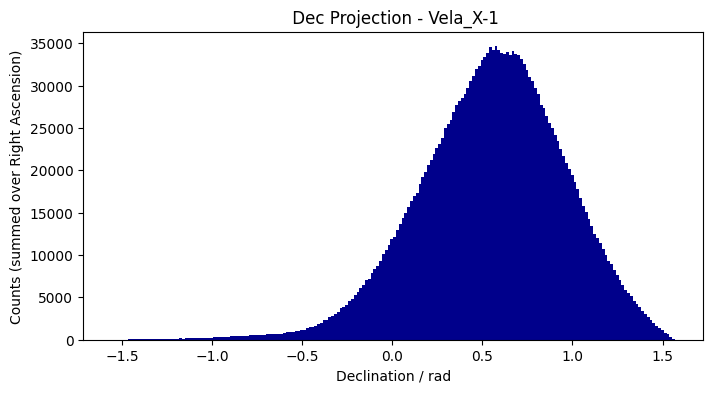

Dec projection plot saved: _200bins_DecProjection.png


In [7]:
source_path = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"
num_bins = 200

from h5py import File
from astropy.table import Table

with File(source_path, 'r') as f:
    source_name = f['source_name'][()].decode('utf-8')
    source_ra = f['skycoord/ra'][()]
    source_dec = f['skycoord/dec'][()]

plot_dec_projection(all_theta_jm,all_phi_jm,event_times, num_bins, "",source_ra,source_dec,source_name,"",'arca')

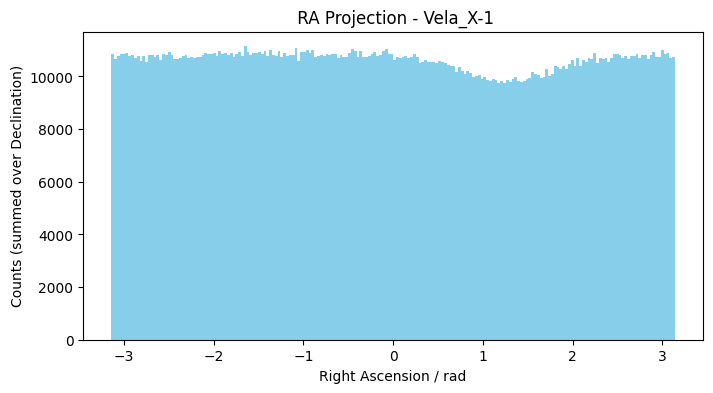

RA projection plot saved: _200bins_RAProjection.png


In [8]:
plot_ra_projection(all_theta_jm,all_phi_jm,event_times, num_bins, "",source_ra,source_dec,source_name,"",'arca')

In [9]:
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

def plot_equatorial_custom(
    evts,
    projection="aitoff",
    ax=None,
    marker="o",
    alpha=0.8,
    markersize =2,
    color='darkblue',
    no_face_colors = False,
    adjust_subplots=True,
    **kwargs,
):
    if no_face_colors is True: 
        kwargs['facecolors']='none'
        kwargs['edgecolors']=color
        kwargs['s']=markersize*12
    else: 
        kwargs['c']=color
        kwargs['s']=markersize

    ra, dec = km3plt.ra_dec(evts)
    if ax is None:
        _, ax = km3plt.projection_axes(projection=projection)
    ax.scatter(np.array(ra), np.array(dec), marker=marker, alpha=alpha, **kwargs)
    if adjust_subplots:
        plt.subplots_adjust(top=0.95, bottom=0.0)
    return ax


def plot_equatorial_hist_skymap(theta,phi,event_times,num_bins,source_ra,source_dec,source_name, output_file, title_prefix="", radius=5*u.deg, circle=False,energy_max_size = None, zero_white_bins = True, smooth_hist = True, detectorname='arca'):

    source_coord = SkyCoord(ra=source_ra * u.deg, dec=source_dec * u.deg)

    
    total_events = len(event_times)
    
    # Convert detector frame angles to sky coordinates (ICRS)
    #event_location_icrs = local_event(theta, phi, astropy_event_times, 'arca').transform_to('icrs')
    event_location_icrs = local_event(theta, phi, event_times, detectorname).transform_to('icrs')

    distances = event_location_icrs.separation(source_coord).degree
    
    # Count selected events
    count_in_circle = np.sum(distances <= radius.value)
    selection_ratio = count_in_circle / total_events if total_events > 0 else 0
    ra_vals, dec_vals = km3plt.ra_dec(event_location_icrs)

    # Define bin edges
    ra_bins = np.linspace(-np.pi, np.pi, num_bins + 1)  # RA in [-π, π]
    dec_bins = np.linspace(-np.pi/2, np.pi/2, num_bins + 1)  # Dec in [-π/2, π/2]

    # Compute 2D histogram
    hist, ra_edges, dec_edges = np.histogram2d(ra_vals, dec_vals, bins=[ra_bins, dec_bins])

    if smooth_hist is True:
        hist_g = gaussian_filter(hist, sigma=1.0)
        if zero_white_bins is True: hist_plot = np.ma.masked_where(hist == 0, hist_g)
        else: hist_plot = hist_g
    else:
        if zero_white_bins is True: hist_plot = np.ma.masked_where(hist == 0, hist)
        else: hist_plot = hist

    # Convert bin centers
    ra_centers = 0.5 * (ra_edges[:-1] + ra_edges[1:])
    dec_centers = 0.5 * (dec_edges[:-1] + dec_edges[1:])
    ra_grid, dec_grid = np.meshgrid(ra_centers, dec_centers, indexing="ij")


    fig, ax = km3plt.projection_axes(projection="aitoff", figsize=(10, 5))

    pc = ax.pcolormesh(ra_bins[:-1], dec_bins[:-1], hist_plot.T, shading="auto")
    plot_equatorial_custom(source_coord, markersize=5, color='deeppink',marker="o", ax=ax, label=source_name, no_face_colors=True)
    
    cbar = plt.colorbar(pc, ax=ax, orientation="horizontal", pad=0.07)
    cbar.set_label("Counts per Bin")
    ax.legend(loc='upper right')

    ax.set_title(f"{title_prefix} Histogram Sky Map for {source_name} \n {total_events} Total Events - {radius} Search Cone - {num_bins} Bins", fontsize=16, pad=30)
    
    # maybe change something here?
    if smooth_hist is True:
        output_plot = output_file + "_" + str(num_bins) + "bins" + "_smooth_HistoSkyMap.png"
    else:
        output_plot = output_file + "_" + str(num_bins) + "bins" + "_HistoSkyMap.png"

135.5286
-40.5547


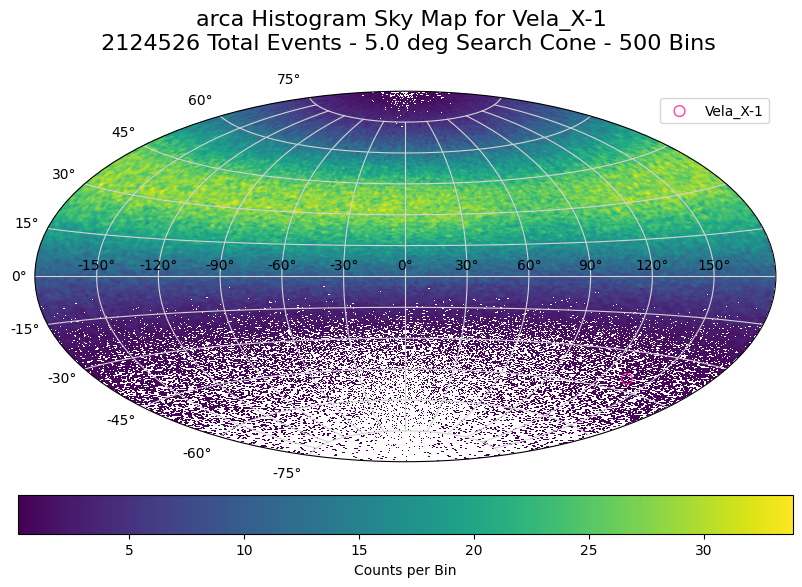

In [10]:
source_path = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/km3net_analysis/inputs/sources/Vela_X-1.h5"
num_bins = 500

from h5py import File
from astropy.table import Table

with File(source_path, 'r') as f:
    source_name = f['source_name'][()].decode('utf-8')
    source_ra = f['skycoord/ra'][()]
    source_dec = f['skycoord/dec'][()]

print(source_ra)
print(source_dec)
plot_equatorial_hist_skymap(all_theta_jm,all_phi_jm,event_times, num_bins,source_ra,source_dec,source_name,"",'arca')

In [11]:
event_times.value

array([1.67045764e+09, 1.67045764e+09, 1.67045764e+09, ...,
       1.67087879e+09, 1.67087879e+09, 1.67087880e+09])

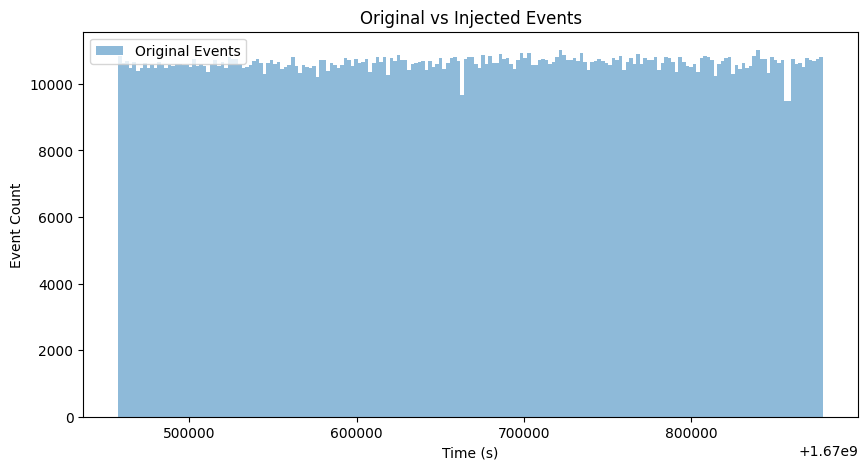

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(event_times.value,bins=200, alpha=0.5, label="Original Events")
#plt.hist(combined_events, bins=100, alpha=0.5, label="Injected Events", color='red')
plt.xlabel("Time (s)")
plt.ylabel("Event Count")
plt.legend()
plt.title("Original vs Injected Events")
plt.show()

In [13]:
def plot_phi_projection(theta, phi, num_bins, output_file, title_prefix="", source_name=""):
    # Compute 2D histogram (same as original)
    hist2d, xedges, yedges = np.histogram2d(phi, theta, bins=num_bins)

    # Project onto phi axis by summing over theta (axis=1 since theta is along the y-axis)
    phi_projection = hist2d.sum(axis=1)

    # Compute phi bin centers
    phi_bin_centers = 0.5 * (xedges[1:] + xedges[:-1])

    # Plot the projection
    plt.figure(figsize=(8, 4))
    plt.bar(phi_bin_centers, phi_projection, width=(xedges[1]-xedges[0]), color='skyblue')
    plt.xlabel("Phi")
    plt.ylabel("Counts (summed over Theta)")
    plt.title(f"{title_prefix} Phi Projection - {source_name}")
    plt.show()
    #output_plot = output_file + f"_{num_bins}bins_PhiProjection.png"
    #plt.savefig(output_plot, bbox_inches='tight')
    #plt.close()

    #print(f"Phi projection plot saved: {output_plot}")

def plot_theta_projection(theta, phi, num_bins, output_file, title_prefix="", source_name=""):
    # Compute 2D histogram
    hist2d, xedges, yedges = np.histogram2d(phi, theta, bins=num_bins)

    # Project onto theta axis by summing over phi (axis=0 since phi is along the x-axis)
    theta_projection = hist2d.sum(axis=0)

    # Compute theta bin centers
    theta_bin_centers = 0.5 * (yedges[1:] + yedges[:-1])

    # Plot the projection
    plt.figure(figsize=(8, 4))
    plt.bar(theta_bin_centers, theta_projection, width=(yedges[1]-yedges[0]), color='darkblue')
    plt.xlabel("Theta")
    plt.ylabel("Counts (summed over Phi)")
    plt.title(f"{title_prefix} Theta Projection - {source_name}")
    plt.show()
    #output_plot = output_file + f"_{num_bins}bins_ThetaProjection.png"
    #plt.savefig(output_plot, bbox_inches='tight')
    #plt.close()

    #print(f"Theta projection plot saved: {output_plot}")

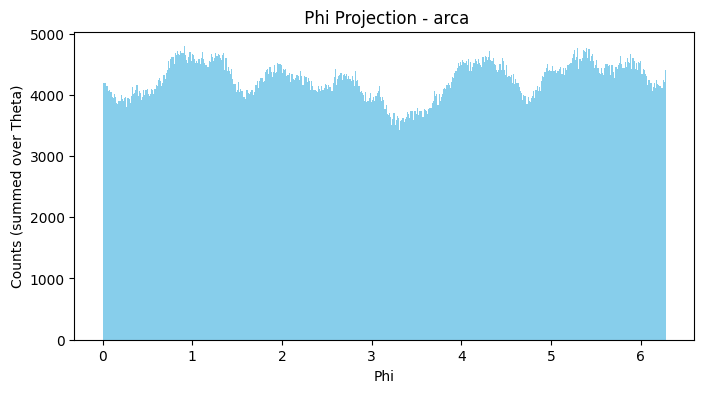

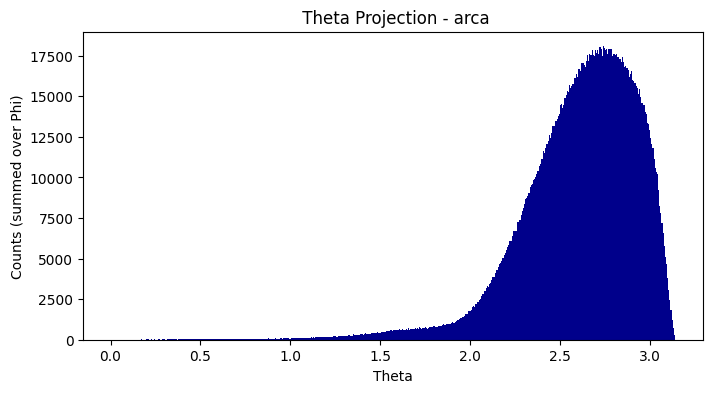

In [14]:
plot_phi_projection(all_theta_jm,all_phi_jm, num_bins,"","",'arca')
plot_theta_projection(all_theta_jm,all_phi_jm, num_bins,"","",'arca')

In [15]:
def plot_theta_phi_hist(theta,phi,event_times,num_bins,source_ra,source_dec,source_name, output_file, title_prefix="", radius=5*u.deg, circle=False,energy_max_size = None, zero_white_bins = True, smooth_hist = True):



    plt.figure(figsize=(8, 5))

    # 2D histogram
    h = plt.hist2d(phi, theta, bins=num_bins, cmap='viridis')
    plt.colorbar(h[3], label='Counts per bin')

    # Mark the source
    #plt.scatter(source_coord.ra.rad, source_coord.dec.rad, s=30, color='deeppink', marker="o", label=source_name)

    plt.xlabel("Phi")
    plt.ylabel("Theta")
    plt.title(f"{title_prefix} Theta/Phi Histogram - {source_name}")
    if smooth_hist is True:
        output_plot = output_file + f"_{num_bins}bins_smooth_Theta_Phi_2DHist.png"
    else:
        output_plot = output_file + f"_{num_bins}bins_Theta_Phi_2DHist.png"
    plt.show()
    #plt.savefig(output_plot, bbox_inches='tight')
    #plt.close()

    #print(f"2D Histogram Theta Phi plot saved: {output_plot}")

import numpy as np
import matplotlib.pyplot as plt
def plot_ra_dec_hist(theta,phi,event_times,num_bins,source_ra,source_dec,source_name, output_file, title_prefix="", radius=5*u.deg, circle=False,energy_max_size = None, zero_white_bins = True, smooth_hist = True, detectorname='arca'):

    source_coord = SkyCoord(ra=source_ra * u.deg, dec=source_dec * u.deg)
    total_events = len(event_times)
    
    # Convert detector frame angles to sky coordinates (ICRS)
    #event_location_icrs = local_event(theta, phi, astropy_event_times, 'arca').transform_to('icrs')
    event_location_icrs = local_event(theta, phi, event_times, detectorname).transform_to('icrs')

    distances = event_location_icrs.separation(source_coord).degree
    
    # Count selected events
    count_in_circle = np.sum(distances <= radius.value)
    selection_ratio = count_in_circle / total_events if total_events > 0 else 0
    ra_vals, dec_vals = km3plt.ra_dec(event_location_icrs)

    plt.figure(figsize=(8, 5))

    # 2D histogram
    h = plt.hist2d(ra_vals, dec_vals, bins=num_bins, cmap='viridis')
    plt.colorbar(h[3], label='Counts per bin')

    plt.scatter(source_coord.ra.rad, source_coord.dec.rad, s=30, facecolors='none', edgecolors='deeppink', marker='o', label=source_name)

    plt.xlabel("Right Ascension / rad")
    plt.ylabel("Declination / rad")
    plt.title(f"{title_prefix} RA/Dec Histogram - {source_name}")
    if smooth_hist is True:
        output_plot = output_file + f"_{num_bins}bins_smooth_RA_Dec_2DHist.png"
    else:
        output_plot = output_file + f"_{num_bins}bins_RA_Dec_2DHist.png"
    plt.show()
    #plt.savefig(output_plot, bbox_inches='tight')
    #plt.close()

    #print(f"2D Histogram plot saved: {output_plot}")



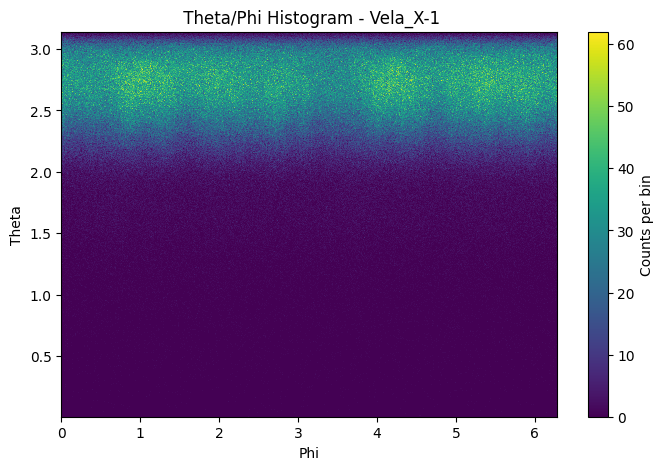

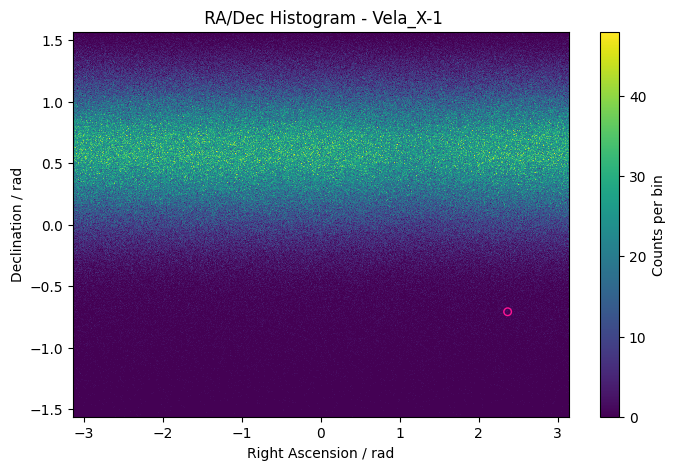

In [16]:
plot_theta_phi_hist(all_theta_jm,all_phi_jm,event_times, num_bins, source_ra,source_dec,source_name,"")
plot_ra_dec_hist(all_theta_jm,all_phi_jm,event_times, num_bins, source_ra,source_dec,source_name,"")

# Sampling Energy from Power Law

In [5]:
from km3io import OfflineReader, tools
import numpy as np
import os
import matplotlib.pyplot as plt

def load_and_combine_energies(file_list_path):

    # Read all file paths from the text file
    with open(file_list_path, "r") as f:
        root_files = [line.strip() for line in f if line.strip()]


    E_jm_list = []
    E_as_list = []
    E_mc_list = []
    E_mc_jm_list = []
    E_mc_as_list = []

    # Loop through each file
    for rootpath_mc in root_files:
        print(f"Processing {rootpath_mc}, size: {os.path.getsize(rootpath_mc) / 1e6:.2f} MB")
        
        # Read the OfflineObject from the file
        OfflineObject_mc = OfflineReader(rootpath_mc)
        print(len(OfflineObject_mc))
        
        # Extract and store best fits and masks for jmuon
        mc_best_fit_jm = tools.best_jmuon(OfflineObject_mc.tracks)
        mc_mask_jm = tools.has_jmuon(OfflineObject_mc.tracks)
        
        # Extract and store best fits and masks for aashower
        mc_best_fit_as = tools.best_aashower(OfflineObject_mc.tracks)
        mc_mask_as = tools.has_aashower(OfflineObject_mc.tracks)

        E_jm = mc_best_fit_jm[mc_mask_jm].E.to_numpy()
        E_as = mc_best_fit_as[mc_mask_as].E.to_numpy()
        E_mc = OfflineObject_mc.mc_trks[:, 0].E.to_numpy()
        E_mc_jm = E_mc[mc_mask_jm]
        E_mc_as = E_mc[mc_mask_as]

        E_jm_list.append(E_jm)
        E_as_list.append(E_as)
        E_mc_list.append(E_mc)
        E_mc_jm_list.append(E_mc_jm)
        E_mc_as_list.append(E_mc_as)

    
    all_E_jm = np.concatenate(E_jm_list)
    all_E_as = np.concatenate(E_as_list)
    all_E_mc = np.concatenate(E_mc_list)
    all_E_mc_jm = np.concatenate(E_mc_jm_list)
    all_E_mc_as = np.concatenate(E_mc_as_list)



    return all_E_jm, all_E_as, all_E_mc, all_E_mc_jm, all_E_mc_as

In [6]:
file_list_path_shower = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/mc_files_arca_anue.txt"
file_list_path_track = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/mc_files_arca_numu.txt"

s_all_E_jm, s_all_E_as, s_all_E_mc, s_all_E_mc_jm, s_all_E_mc_as = load_and_combine_energies(file_list_path_shower)
t_all_E_jm, t_all_E_as, t_all_E_mc, t_all_E_mc_jm, t_all_E_mc_as = load_and_combine_energies(file_list_path_track)

file_list_path_combined = "/home/hpc/capn/capn107h/software/psr/workflows/km3net/mc_files_arca.txt"
c_all_E_jm, c_all_E_as, c_all_E_mc, c_all_E_mc_jm, c_all_E_mc_as = load_and_combine_energies(file_list_path_combined)


Processing /home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013288.jchain.aashower.1.root, size: 1626.55 MB
13274
Processing /home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013289.jchain.aashower.2.root, size: 1630.48 MB
13309
Processing /home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013290.jchain.aashower.3.root, size: 1623.73 MB
13312
Processing /home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013291.jchain.aashower.4.root, size: 1641.52 MB
13244
Processing /home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013292.jchain.aashower.5.root, size: 1613.89 MB
13466
Processing /home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013293.jchain.aashower.6.root, size: 1650.78 MB
13348
Processing /home/wecapstor3/capn/capn107h/mc/mcv8.1.gsg_anue-CCHEDIS_1e2-1e8GeV.sirene.jterbr00013294.jcha

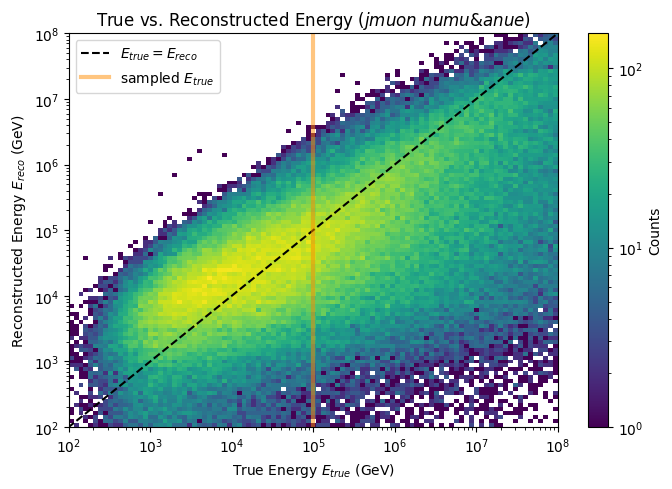

In [102]:
E_mc = c_all_E_mc_jm
E_reco = c_all_E_jm

valid_mask = (
    ~np.isnan(E_mc) & 
    ~np.isnan(E_reco) & 
    (E_mc != 0) & 
    (E_reco != 0)
)

E_mc_clean = E_mc[valid_mask]
E_reco_clean = E_reco[valid_mask]

#bins_true = np.logspace(np.log10(E_mc_clean.min()), np.log10(E_mc_clean.max()), 100)
#bins_reco = np.logspace(np.log10(E_reco_clean.min()), np.log10(E_reco_clean.max()), 100)

bins_true = np.logspace(np.log10(1e2), np.log10(1e8), 100)
bins_reco = np.logspace(np.log10(1e2), np.log10(1e8), 100)

# 2D histogram: rows = true, columns = reco
hist2d, xedges, yedges = np.histogram2d(E_mc_clean, E_reco_clean, bins=[bins_true, bins_reco])

E_combined = np.concatenate([E_mc_clean, E_reco_clean])
E_min = E_combined.min()
E_max = E_combined.max()

E_true_sampled = 1e5  # Example true energy


# Plot it
plt.figure(figsize=(7, 5))
plt.pcolormesh(xedges, yedges, hist2d.T, norm='log', shading='auto')

# Plot the 45-degree line (E_mc = E_reco)
plt.plot([E_min, E_max], [E_min, E_max], color='k', linestyle='--', label=r'$E_{true} = E_{reco}$')
plt.axvline(E_true_sampled, color= "darkorange", lw=3,alpha=0.5, label = r"sampled $E_{true}$")

plt.xscale('log')
plt.yscale('log')
#plt.xlim(E_min, E_max)
#plt.ylim(E_min, E_max)
plt.ylim(1e2,1e8)
plt.xlim(1e2,1e8)
plt.xlabel(r"True Energy $E_{true}$ (GeV)")
plt.ylabel(r"Reconstructed Energy $E_{reco}$ (GeV)")
plt.title(r"True vs. Reconstructed Energy ($\it{jmuon}$ $\it{numu&anue}$)")
plt.colorbar(label='Counts')
plt.legend()
plt.tight_layout()
plt.show()

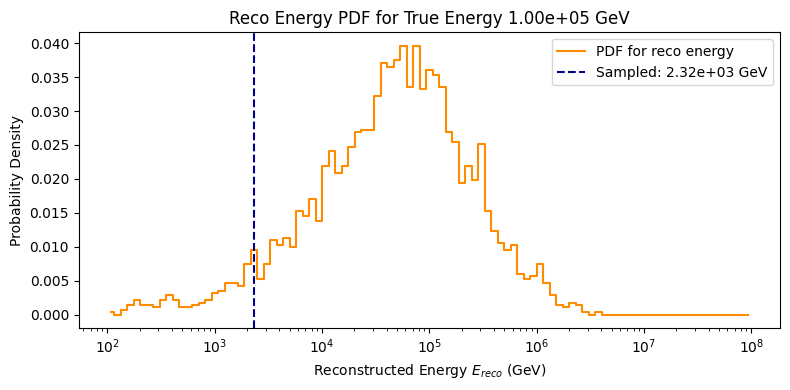

2315.755523011798


In [103]:
E_true_sampled = 1e5  # Example true energy

# Find the bin index for the true energy
true_bin_idx = np.digitize(E_true_sampled, bins_true) - 1

# Get the histogram slice
slice_hist = hist2d[true_bin_idx, :]

# Define centers of reco bins for plotting
bin_centers_reco = 0.5 * (yedges[1:] + yedges[:-1])

# Normalize slice to use as PDF
pdf = slice_hist / np.sum(slice_hist) if np.sum(slice_hist) > 0 else np.zeros_like(slice_hist)

# Sample from the reconstructed energy distribution
reco_sampled = np.random.choice(bin_centers_reco, p=pdf)

# Plot the PDF and sampled value
plt.figure(figsize=(8, 4))
plt.plot(bin_centers_reco, pdf, drawstyle='steps-mid', color="darkorange", label='PDF for reco energy')
plt.axvline(reco_sampled, color='darkblue', linestyle='--', label=f'Sampled: {reco_sampled:.2e} GeV')
plt.xscale('log')
plt.xlabel(r"Reconstructed Energy $E_{reco}$ (GeV)")
plt.ylabel("Probability Density")
plt.title(f"Reco Energy PDF for True Energy {E_true_sampled:.2e} GeV")
plt.legend()
plt.tight_layout()
plt.show()

print(reco_sampled)


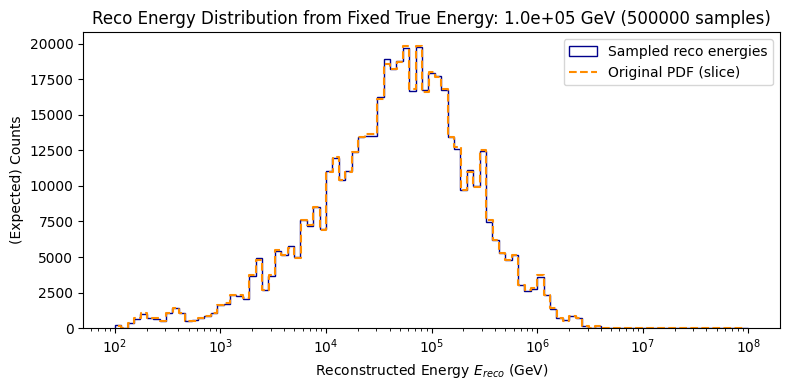

In [ ]:
def sample_reco_from_true(E_true_fixed, hist2d, bins_true, bins_reco, n_samples=5000):
    """
    Sample reconstructed energies from a fixed true energy using the 2D histogram.

    Parameters:
        E_true_fixed : float
            The fixed true energy to sample reco energies for.
        hist2d : 2D np.array
            2D histogram of (true, reco) energy.
        bins_true : np.array
            Bin edges for true energy.
        bins_reco : np.array
            Bin edges for reconstructed energy.
        n_samples : int
            Number of reco samples to generate.

    Returns:
        reco_samples : np.array
            Array of sampled reconstructed energies.
        pdf : np.array
            PDF used for sampling.
        bin_centers_reco : np.array
            Bin centers of the reco axis.
    """
    # Find the bin index corresponding to E_true_fixed
    true_bin_idx = np.digitize(E_true_fixed, bins_true) - 1

    if true_bin_idx < 0 or true_bin_idx >= hist2d.shape[0]:
        raise ValueError("E_true_fixed is outside the bin range.")

    # Get the histogram slice for this true energy
    slice_hist = hist2d[true_bin_idx, :]
    total = np.sum(slice_hist)
    if total == 0:
        raise ValueError("Histogram slice for this E_true is empty.")

    # Normalize slice to form a PDF
    pdf = slice_hist / total
    bin_centers_reco = 0.5 * (bins_reco[1:] + bins_reco[:-1])

    # Sample reconstructed energies from this PDF
    reco_samples = np.random.choice(bin_centers_reco, size=n_samples, p=pdf)

    return reco_samples, pdf, bin_centers_reco


E_true_fixed = 1e5  # example fixed true energy
n_samples = 500000
# Sample reco energies
reco_samples, pdf, bin_centers = sample_reco_from_true(
    E_true_fixed,
    hist2d,
    bins_true,
    bins_reco,
    n_samples
)

# Plot histogram of sampled reco energies and the original PDF
plt.figure(figsize=(8, 4))

# Histogram of sampled reco energies
plt.hist(reco_samples, bins=bins_reco, histtype='step', color='darkblue', label='Sampled reco energies')

# Plot original PDF used for sampling
plt.step(bin_centers, pdf*len(reco_samples), color='darkorange', where='mid', linestyle='--', label='Original PDF (slice)')
#plt.step(bins_reco[:-1], pdf * len(reco_samples), where='mid', color='darkorange', linestyle='--', label='Original PDF (slice)')

plt.xscale('log')
plt.xlabel(r"Reconstructed Energy $E_{reco}$ (GeV)")
plt.ylabel("(Expected) Counts")
plt.title(f"Reco Energy Distribution from Fixed True Energy: {E_true_fixed:.2e} GeV ({n_samples} samples)")
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
import numpy as np

def sample_power_law_energies(n, E_min, E_max, gamma, E_cut):
    """
    Sample energies from a power-law with exponential cutoff.

    Parameters:
        n : int
            Number of energies to sample.
        E_min : float
            Minimum energy.
        E_max : float
            Maximum energy.
        gamma : float
            Power-law index.
        E_cut : float
            Exponential cutoff energy.

    Returns:
        np.array of sampled energies.
    """
    from scipy.stats import rv_continuous
    from scipy.integrate import quad

    class PowerLawCutoff(rv_continuous):
        def _pdf(self, E):
            return E**(-gamma) * np.exp(-E / E_cut)

    # Normalize PDF
    dist = PowerLawCutoff(a=E_min, b=E_max, name='powerlaw_cutoff')
    norm = quad(dist._pdf, E_min, E_max)[0]
    dist._pdf = lambda E: (E**(-gamma) * np.exp(-E / E_cut)) / norm

    return dist.rvs(size=n)


new_event_energies = sample_power_law_energies(
    n=int(len(energy)*1e2),
    E_min=5e4,       # Adjust as needed
    E_max=7e5,     # Adjust as needed
    gamma=2.0,       # Slope of the spectrum
    E_cut=7e5       # Energy cutoff
)

def inject_event(hist2d, bins_true, bins_reco, E_true_sampled):
    idx = np.digitize(E_true_sampled, bins_true) - 1
    slice_hist = hist2d[idx, :]
    pdf = slice_hist / np.sum(slice_hist) if np.sum(slice_hist) > 0 else np.zeros_like(slice_hist)
    bin_centers_reco = 0.5 * (bins_reco[1:] + bins_reco[:-1])
    return np.random.choice(bin_centers_reco, p=pdf)

E_true = sample_power_law_energies(1, E_min=5e4, E_max=7e5, gamma=2.0, E_cut=7e5)[0]
E_reco_sampled = inject_event(hist2d, bins_true, bins_reco, E_true)


NameError: name 'energy' is not defined